# IMPORT LIBRARY

In [1]:
import torch
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA version (compiled): {torch.version.cuda}")
print(f"cuDNN version: {torch.backends.cudnn.version()}")
print(f"GPU: {torch.cuda.get_device_name(0)}")

# Compute capability
cc = torch.cuda.get_device_capability(0)
print(f"Compute Capability: {cc[0]}.{cc[1]}")

# Test đơn giản xem CUDA có chạy được không
x = torch.randn(2, 2).cuda()
y = x @ x
print(f"CUDA test OK: {y.shape}")

PyTorch version: 2.5.1+cu121
CUDA version (compiled): 12.1
cuDNN version: 90100
GPU: NVIDIA GeForce RTX 4050 Laptop GPU
Compute Capability: 8.9
CUDA test OK: torch.Size([2, 2])


In [2]:
import os
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"  # Đặt biến môi trường để giúp debug lỗi CUDA
os.environ["TORCH_USE_CUDA_DSA"] = "True"
os.environ["TORCH_CUDA_ARCH_LIST"] = "8.9"
import gc

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from pathlib import Path
import time
import wandb
import numpy as np
import torch
from scipy.ndimage import distance_transform_edt
from tqdm import tqdm

import numpy as np

import nibabel as nib
import matplotlib.pyplot as plt

from scipy.ndimage import zoom as nd_zoom, center_of_mass
from sklearn.model_selection import train_test_split

from torch.optim import Adam

import multiprocessing
multiprocessing.set_start_method('spawn', force=True)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device_id = torch.cuda.current_device()
device_name = torch.cuda.get_device_name(device_id)

allocated = torch.cuda.memory_allocated(device_id) / (1024**2)
# Bộ nhớ tối đa từng bị chiếm dụng (Max Allocated)
max_allocated = torch.cuda.max_memory_allocated(device_id) / (1024**2)
# Bộ nhớ đang được cache bởi PyTorch giữ lại (Reserved/Cached)
reserved = torch.cuda.memory_reserved(device_id) / (1024**2)

print(f"🖥️  Thiết bị: {device_name} (ID: {device_id})")
print(f"   - Đang cấp phát (Allocated):  {allocated:.2f} MB")
print(f"   - Đạt đỉnh (Max Allocated):  {max_allocated:.2f} MB")
print(f"   - Đang dự trữ (Reserved):     {reserved:.2f} MB")

gc.collect()
torch.cuda.empty_cache()
torch.cuda.reset_peak_memory_stats()

print(f"device: {device}")
print(f"torch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"cuDNN version: {torch.backends.cudnn.version()}")
print(f"Graphics card: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'N/A'}")

print(f"   - Đang cấp phát (Allocated):  {allocated:.2f} MB")
print(f"   - Đạt đỉnh (Max Allocated):  {max_allocated:.2f} MB")
print(f"   - Đang dự trữ (Reserved):     {reserved:.2f} MB")

🖥️  Thiết bị: NVIDIA GeForce RTX 4050 Laptop GPU (ID: 0)
   - Đang cấp phát (Allocated):  8.13 MB
   - Đạt đỉnh (Max Allocated):  8.13 MB
   - Đang dự trữ (Reserved):     22.00 MB
device: cuda
torch version: 2.5.1+cu121
CUDA available: True
cuDNN version: 90100
Graphics card: NVIDIA GeForce RTX 4050 Laptop GPU
   - Đang cấp phát (Allocated):  8.13 MB
   - Đạt đỉnh (Max Allocated):  8.13 MB
   - Đang dự trữ (Reserved):     22.00 MB


# SQUEEZE EXCITATION

In [3]:
class SqueezeExcitation(nn.Module):
    """Squeeze and Excitation (SE) Attention Block"""
    def __init__(self, channels, reduction=16):
        super(SqueezeExcitation, self).__init__()
        self.global_avg_pool = nn.AdaptiveAvgPool3d(1)
        self.fc = nn.Sequential(
            nn.Linear(channels, channels // reduction, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(channels // reduction, channels, bias=False),
            nn.Sigmoid()
        )
    
    def forward(self, x):
        b, c, d, h, w = x.size()
        y = self.global_avg_pool(x).view(b, c)
        y = self.fc(y).view(b, c, 1, 1, 1)
        return x * y.expand_as(x)

# PARALLEL CONVOLUTION

In [4]:
class ParallelConvolutionBlock(nn.Module):
    """
    PC Block theo paper Fig.2:
    shared 3x3x3 embed → 3 parallel paths (1x1x1, 3x3x3, 5x5x5) → maxpool → concat
    Không có BatchNorm (paper không đề cập norm trong PC block)
    """
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.shared_conv = nn.Conv3d(in_channels, out_channels, kernel_size=3, padding=1)
        self.relu = nn.LeakyReLU(negative_slope=0.1, inplace=True)

        self.conv1 = nn.Conv3d(out_channels, out_channels, kernel_size=1, padding=0)
        self.conv3 = nn.Conv3d(out_channels, out_channels, kernel_size=3, padding=1)
        self.conv5 = nn.Conv3d(out_channels, out_channels, kernel_size=5, padding=2)
        self.pool  = nn.MaxPool3d(kernel_size=2, stride=2)

    def forward_with_skip(self, x):
        """Trả về (x_shared, pc_out) để LATUPNet dùng x_shared làm skip connection."""
        x_shared = self.relu(self.shared_conv(x))          # (B, out_ch, H, W, D) — full res
        path1 = self.pool(self.relu(self.conv1(x_shared)))
        path2 = self.pool(self.relu(self.conv3(x_shared)))
        path3 = self.pool(self.relu(self.conv5(x_shared)))
        pc_out = torch.cat([path1, path2, path3], dim=1)   # (B, out_ch*3, H/2, W/2, D/2)
        return x_shared, pc_out

    def forward(self, x):
        _, pc_out = self.forward_with_skip(x)
        return pc_out

# ENCODER

In [5]:
class EncoderBlock(nn.Module):
    """
    Theo Table 1 paper: SE → Conv → InstanceNorm → Conv → Dropout → MaxPool
    SE đặt TRƯỚC hai conv, không phải sau.
    """
    def __init__(self, in_channels, out_channels, use_se=True, dropout_rate=0.2):
        super().__init__()
        self.se = SqueezeExcitation(in_channels) if use_se else nn.Identity()

        self.conv1 = nn.Conv3d(in_channels, out_channels, kernel_size=3, padding=1)
        self.norm1 = nn.InstanceNorm3d(out_channels, affine=True)
        self.relu  = nn.LeakyReLU(negative_slope=0.1, inplace=True)

        self.conv2 = nn.Conv3d(out_channels, out_channels, kernel_size=3, padding=1)
        # Paper không đề cập InstanceNorm sau conv2 trong encoder, nhưng Table 1 có
        self.norm2 = nn.InstanceNorm3d(out_channels, affine=True)

        self.dropout = nn.Dropout3d(dropout_rate)
        self.pool    = nn.MaxPool3d(kernel_size=2, stride=2)

    def forward(self, x):
        x = self.se(x)                            # SE trước
        x = self.relu(self.norm1(self.conv1(x)))
        x = self.relu(self.norm2(self.conv2(x)))
        x = self.dropout(x)
        skip = x                                   # skip trước pooling
        x = self.pool(x)
        return x, skip

# DECODER

In [6]:
class DecoderBlock(nn.Module):
    """
    Theo Table 1: Upsample → Conv → InstanceNorm → SE → Concat(skip) → Conv
    SE đặt GIỮA hai conv (sau conv1, trước concat+conv2) — đúng paper Section 3.
    """
    def __init__(self, in_channels, skip_channels, out_channels, use_se=True, dropout_rate=0.2):
        super().__init__()
        self.upsample = nn.Upsample(scale_factor=2, mode='trilinear', align_corners=False)

        self.conv1 = nn.Conv3d(in_channels, out_channels, kernel_size=3, padding=1)
        self.norm1 = nn.InstanceNorm3d(out_channels, affine=True)
        self.relu  = nn.LeakyReLU(negative_slope=0.1, inplace=True)

        self.se = SqueezeExcitation(out_channels) if use_se else nn.Identity()

        self.conv2   = nn.Conv3d(out_channels + skip_channels, out_channels, kernel_size=3, padding=1)
        self.norm2   = nn.InstanceNorm3d(out_channels, affine=True)
        self.dropout = nn.Dropout3d(dropout_rate)

    def forward(self, x, skip):
        x = self.upsample(x)
        x = self.relu(self.norm1(self.conv1(x)))
        x = self.se(x)
        if x.shape[2:] != skip.shape[2:]:
            skip = F.interpolate(skip, size=x.shape[2:], mode='trilinear', align_corners=False)
        x = torch.cat([x, skip], dim=1)
        x = self.relu(self.norm2(self.conv2(x)))
        x = self.dropout(x)
        return x

# LATUP-NET MODEL

In [7]:
class LATUPNet(nn.Module):
    """
    LATUP-Net theo đúng Table 1 paper:
    - Input: (B, 3, 128, 128, 128)  — T2, T1ce, FLAIR (không có T1, Section 4.1)
    - 3 encoder blocks (PC + enc2 + enc3)
    - 3 decoder blocks (dec3 + dec2 + dec1)
    - Output: (B, 4, 128, 128, 128)
    """
    def __init__(self, in_channels=3, num_classes=3, use_se=True, dropout_rate=0.2):
        super().__init__()

        # PC block: (B,3,128,128,128) → (B,96,64,64,64)
        self.pc_block = ParallelConvolutionBlock(in_channels, 32)

        # Encoder 2: (B,96,64,64,64) → (B,64,32,32,32), skip1: (B,64,64,64,64)
        self.enc2 = EncoderBlock(96, 64, use_se=use_se, dropout_rate=dropout_rate)
        # Encoder 3: (B,64,32,32,32) → (B,128,16,16,16), skip2: (B,128,32,32,32)
        self.enc3 = EncoderBlock(64, 128, use_se=use_se, dropout_rate=dropout_rate)

        # Bottleneck SE (Table 1: SE Layer_3 at bottleneck)
        self.bottleneck_se = SqueezeExcitation(128) if use_se else nn.Identity()

        # Decoder 3: (B,128,16,16,16) + skip2(B,128,32,32,32) → (B,128,32,32,32)
        self.dec3 = DecoderBlock(128, 128, 128, use_se=use_se, dropout_rate=dropout_rate)
        # Decoder 2: (B,128,32,32,32) + skip1(B,64,64,64,64) — wait, skip1 là 64ch
        # Theo Table 1: dec2 concat shape (64,64,64,128) → out 64
        self.dec2 = DecoderBlock(128, 64, 64, use_se=use_se, dropout_rate=dropout_rate)
        # Decoder 1: (B,64,64,64,64) upsample → (B,128,128,128) + skip_pc
        # skip từ PC block output (B,96,64,64,64) — nhưng paper dùng skip từ PC trước pool
        # Table 1 dec1_concat shape: (128,128,128,64) → paper dùng skip của PC embedded (32ch trước pool)
        # dec1: conv1 64→32, concat skip_pc(32ch per path? không) 
        # Theo Table 1 chính xác: dec1_conv1 input=64→32, concat→64ch, conv2 64→32
        self.dec1 = DecoderBlock(64, 32, 32, use_se=False, dropout_rate=dropout_rate)

        # Final 1x1x1 conv → softmax (paper Section 3)
        self.final_conv = nn.Conv3d(32, num_classes, kernel_size=1)

        self._initialize_weights()

    def _initialize_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv3d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='leaky_relu')
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.InstanceNorm3d):
                if m.weight is not None:
                    nn.init.constant_(m.weight, 1)
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)

    def forward(self, x):
        # PC block — lưu skip từ shared conv (trước pool) theo Table 1 dec1_concat
        # Table 1: dec1_concat input (128,128,128,32) → skip là output shared_conv (32ch, full res)
        # Tuy nhiên paper Fig.1 cho thấy skip từ PC là toàn bộ PC output trước pool
        # Theo Table 1 dec1_concat shape=(128,128,128,64): 32(dec1_conv1 out) + 32(skip_pc shared) = 64 ✓
        x_shared = self.pc_block.relu(self.pc_block.shared_conv(x))  # (B,32,128,128,128)
        skip_pc  = x_shared

        x = self.pc_block.pool(self.pc_block.relu(self.pc_block.conv1(x_shared)))
        p2 = self.pc_block.pool(self.pc_block.relu(self.pc_block.conv3(x_shared)))
        p3 = self.pc_block.pool(self.pc_block.relu(self.pc_block.conv5(x_shared)))
        x = torch.cat([x, p2, p3], dim=1)       # (B,96,64,64,64)

        x, skip2 = self.enc2(x)                  # x:(B,64,32,32,32), skip2:(B,64,64,64,64)
        x, skip3 = self.enc3(x)                  # x:(B,128,16,16,16), skip3:(B,128,32,32,32)

        x = self.bottleneck_se(x)                # (B,128,16,16,16)

        x = self.dec3(x, skip3)                  # (B,128,32,32,32)
        x = self.dec2(x, skip2)                  # (B,64,64,64,64)
        x = self.dec1(x, skip_pc)                # (B,32,128,128,128)

        return self.final_conv(x)                 # (B,4,128,128,128) — full res, no extra upsample needed

# DICE LOSS

In [8]:
class WeightedDiceLoss(nn.Module):
    """
    WDL theo đúng Eq.(3) và (4) trong paper:
    Tính DSL riêng cho NCR/NET (ch1), ED (ch2), ET (ch4→ch3 trong output)
    Không gộp region trước khi tính — weight theo region importance sau.
    
    w_WT=1.64, w_TC=2.55, w_ET=3.40  (ENet formula, paper Section 4.3)
    WDL = (w_WT+w_TC+w_ET)*DSL_ET + (w_WT+w_TC)*DSL_NCR + w_WT*DSL_ED
    """
    def __init__(self, epsilon=1e-5):
        super().__init__()
        self.epsilon = epsilon
        self.w_wt = 4.51
        self.w_tc = 5.37
        self.w_et = 6.12

    def _dice_loss(self, pred, target):
        pred_f   = pred.contiguous().view(-1)
        target_f = target.contiguous().view(-1)
        intersection = (pred_f * target_f).sum()
        return 1.0 - (2. * intersection + self.epsilon) / (
            pred_f.pow(2).sum() + target_f.pow(2).sum() + self.epsilon
        )

    def forward(self, pred, target):
        """
        pred:   (B, 4, H, W, D) — logits, channels: [BG, NCR/NET, ED, ET]
        target: (B, H, W, D)    — labels {0,1,2,4} (BraTS convention)
        """
        pred_soft = F.softmax(pred, dim=1)

        # One-hot targets theo channel BraTS: label4 → channel3
        target_ncr = (target == 1).float()
        target_ed  = (target == 2).float()
        target_et  = (target == 4).float()          # target vẫn giữ label BraTS gốc {0,1,2,4}

        dsl_ncr = self._dice_loss(pred_soft[:, 1], target_ncr)
        dsl_ed  = self._dice_loss(pred_soft[:, 2], target_ed)
        dsl_et  = self._dice_loss(pred_soft[:, 3], target_et)

        # Eq.(4) paper
        wdl = (self.w_wt + self.w_tc + self.w_et) * dsl_et \
            + (self.w_wt + self.w_tc)              * dsl_ncr \
            + self.w_wt                             * dsl_ed

        return wdl

In [9]:
# Create model
model = LATUPNet(in_channels=3, num_classes=4, use_se=True, dropout_rate=0.2)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print("=" * 60)
print("LATUP-Net Model Summary")
print("=" * 60)
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"Parameter count: {trainable_params / 1e6:.2f}M")
print(f"Expected: ~3.07M parameters (as reported in paper)")

# Test forward pass
batch_size = 1
depth, height, width = 128, 128, 128
channels = 3

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)
model.eval()

x = torch.randn(batch_size, channels, depth, height, width).to(device)

print(f"\nInput shape: {x.shape}")

with torch.no_grad():
    output = model(x)

print(f"Output shape: {output.shape}")

# Verify channel flow
print(f"\nChannel flow verification:")
print(f"  Input: {channels} channels")
print(f"  After PC block: 96 channels")
print(f"  After Enc1: 64 channels (skip: 64)")
print(f"  After Enc2: 128 channels (skip: 128)")
print(f"  After Bottleneck: 128 channels")
print(f"  After Dec2: 64 channels")
print(f"  After Dec1: 32 channels")
print(f"  Final output: 4 channels (BG, NCR/NET, ED, ET)")

# Test loss function
target = torch.randint(0, 5, (batch_size, depth, height, width)).to(device)
target[target == 3] = 4  # Ensure BraTS label convention

criterion = WeightedDiceLoss()
loss = criterion(output, target)
print(f"\nWeighted Dice Loss: {loss.item():.4f}")

print("\n" + "=" * 60)
print("Model structure:")
print("=" * 60)
print(model)

LATUP-Net Model Summary
Total parameters: 2,988,388
Trainable parameters: 2,988,388
Parameter count: 2.99M
Expected: ~3.07M parameters (as reported in paper)

Input shape: torch.Size([1, 3, 128, 128, 128])
Output shape: torch.Size([1, 4, 128, 128, 128])

Channel flow verification:
  Input: 3 channels
  After PC block: 96 channels
  After Enc1: 64 channels (skip: 64)
  After Enc2: 128 channels (skip: 128)
  After Bottleneck: 128 channels
  After Dec2: 64 channels
  After Dec1: 32 channels
  Final output: 4 channels (BG, NCR/NET, ED, ET)

Weighted Dice Loss: 22.7936

Model structure:
LATUPNet(
  (pc_block): ParallelConvolutionBlock(
    (shared_conv): Conv3d(3, 32, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
    (relu): LeakyReLU(negative_slope=0.1, inplace=True)
    (conv1): Conv3d(32, 32, kernel_size=(1, 1, 1), stride=(1, 1, 1))
    (conv3): Conv3d(32, 32, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
    (conv5): Conv3d(32, 32, kernel_size=(5, 5, 5), stri

# PRE-PROCESSING DATA

In [10]:
def find_volume(patient_dir, patient_id, modality):
    """Find a valid .nii or .nii.gz file for one BraTS modality, handling inconsistent naming."""
    patient_dir = Path(patient_dir)
    
    # 1. Định nghĩa các mẫu từ khóa tìm kiếm cho từng modality (bất kể viết hoa/thường)
    modality_lower = modality.lower()
    
    if modality_lower == "seg":
        # Tìm các file chứa "seg" hoặc "segm" (để xử lý case bệnh nhân 355)
        search_patterns = ["*seg*.nii", "*seg*.nii.gz", "*Segm*.nii", "*Segm*.nii.gz"]
    else:
        # Với t1, t1ce, t2, flair: tìm file chứa đúng từ khóa đó (ví dụ: *_flair.nii)
        search_patterns = [f"*{modality_lower}.nii", f"*{modality_lower}.nii.gz"]

    # 2. Quét qua các mẫu để tìm file thực tế trong thư mục
    for pattern in search_patterns:
        # Chạy glob không phân biệt hoa thường (trên Windows/Linux tùy cấu hình, dùng rglob/glob)
        hits = list(patient_dir.glob(pattern))
        
        # Nếu không thấy, thử tìm phiên bản viết hoa chữ cái đầu (như Flair, T1ce...)
        if not hits:
            hits = list(patient_dir.glob(pattern.capitalize()))
            
        for path in hits:
            # Kiểm tra xem file có hợp lệ (tồn tại và không trống) không
            if path.exists() and path.stat().st_size > 0:
                return path

    # 3. Nếu không tìm thấy bằng glob, quay lại fallback cơ bản (để hiển thị danh sách đã thử)
    candidates = [
        patient_dir / f"{patient_id}_{modality}.nii",
        patient_dir / f"{patient_id}_{modality}.nii.gz",
    ]
    tried = [str(p) for p in candidates] + [str(patient_dir / p) for p in search_patterns]
    
    zip_candidates = [patient_dir / f"{patient_id}_{modality}.nii.zip"]
    zip_hits = [p for p in zip_candidates if p.exists()]
    zip_note = ""
    if zip_hits:
        zip_note = "\nFound .zip files. Extract them before loading NIfTI data:\n" + "\n".join(map(str, zip_hits))

    raise FileNotFoundError(
        f"Could not find modality '{modality}' for {patient_id} in {patient_dir}. Tried patterns:\n"
        + "\n".join(tried)
        + zip_note
    )


def load_volume(patient_dir, patient_id, modality):
    path = find_volume(patient_dir, patient_id, modality)
    img = nib.load(str(path))
    data = img.get_fdata(dtype=np.float32)
    # print(f"Loaded {modality:5s}: {path.name} | shape={data.shape} | dtype={data.dtype}")
    return data, img

Đang hiển thị lát cắt thứ 77 của bệnh nhân BraTS20_Training_001
Kích thước khối ảnh: (240, 240, 155)


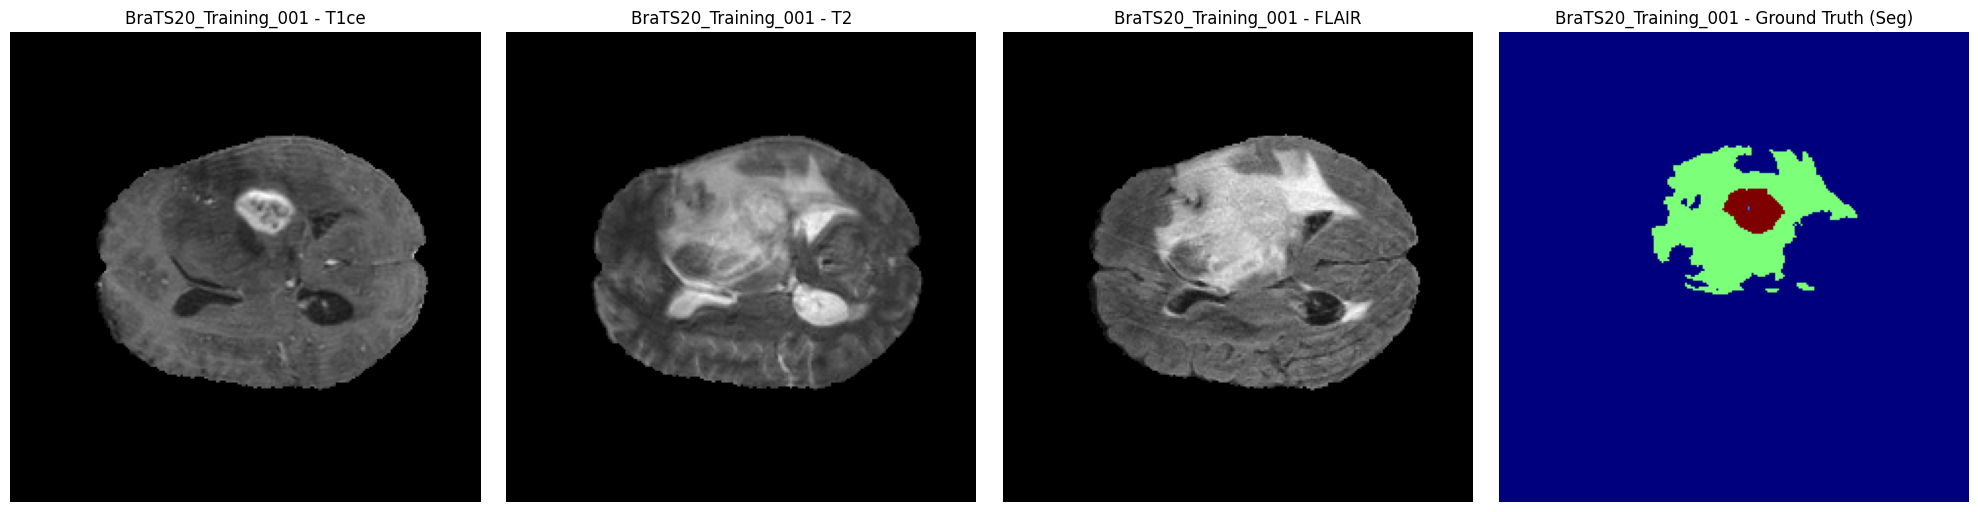

In [11]:
PATIENT_DIR = "BraTS2020/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData/BraTS20_Training_001"
PATIENT_ID = Path(PATIENT_DIR).name

modalities = ["t1ce", "t2", "flair", "seg"]
volumes = {}
slice_idx = None  # Mặc định sẽ lấy lát cắt chính giữa

# 1. Load toàn bộ các chuỗi xung và mask giải phẫu
for mod in modalities:
    try:
        volumes[mod], _ = load_volume(PATIENT_DIR, PATIENT_ID, mod)
    except Exception as e:
        print(f"Lỗi khi load chuỗi {mod}: {e}")

# 2. Xác định lát cắt để hiển thị (Mặc định lấy lát cắt chính giữa khối ảnh)
# Ảnh BraTS thường có shape (H, W, D) ví dụ (240, 240, 155) -> lấy tâm theo chiều dọc D
if slice_idx is None:
    slice_idx = volumes["flair"].shape[2] // 2

print(f"Đang hiển thị lát cắt thứ {slice_idx} của bệnh nhân {PATIENT_ID}")
print(f"Kích thước khối ảnh: {volumes['flair'].shape}")

# 3. Khởi tạo biểu đồ Matplotlib (1 hàng, 4 cột)
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

# Chuỗi 1: T1ce
axes[0].imshow(volumes["t1ce"][:, :, slice_idx], cmap="gray")
axes[0].set_title(f"{PATIENT_ID} - T1ce")
axes[0].axis("off")

# Chuỗi 2: T2
axes[1].imshow(volumes["t2"][:, :, slice_idx], cmap="gray")
axes[1].set_title(f"{PATIENT_ID} - T2")
axes[1].axis("off")

# Chuỗi 3: FLAIR
axes[2].imshow(volumes["flair"][:, :, slice_idx], cmap="gray")
axes[2].set_title(f"{PATIENT_ID} - FLAIR")
axes[2].axis("off")

# Chuỗi 4: Segmentation Mask (Dùng cmap màu khác để nổi bật vùng u)
# BraTS có các nhãn: 0 (Nền), 1 (NCR/NET), 2 (ED), 4 (ET)
axes[3].imshow(volumes["seg"][:, :, slice_idx], cmap="jet")
axes[3].set_title(f"{PATIENT_ID} - Ground Truth (Seg)")
axes[3].axis("off")

plt.tight_layout()
plt.show()

In [12]:
def resample_volume(volume, original_spacing, target_spacing=(1,1,1), order=1):
    zoom_factors = [o/t for o,t in zip(original_spacing, target_spacing)]
    return nd_zoom(volume, zoom_factors, order=order)

In [13]:
# Hàm bổ trợ cắt ảnh lấy tâm (Center Crop hoặc Pad nếu thiếu)
def crop_or_pad_3d(volume, target_shape=(128, 128, 128)):
    current_shape = volume.shape
    new_volume = np.zeros(target_shape, dtype=volume.dtype)
    
    # Tính toán chỉ số để cắt hoặc chèn cho từng chiều
    slices_src = []
    slices_dst = []
    
    for c, t in zip(current_shape, target_shape):
        if c >= t:
            # Nếu ảnh lớn hơn target -> Cắt lấy tâm
            start = (c - t) // 2
            slices_src.append(slice(start, start + t))
            slices_dst.append(slice(0, t))
        else:
            # Nếu ảnh nhỏ hơn target -> Chèn vào giữa (Padding)
            start = (t - c) // 2
            slices_src.append(slice(0, c))
            slices_dst.append(slice(start, start + c))
            
    new_volume[tuple(slices_dst)] = volume[tuple(slices_src)]
    return new_volume

Unique labels in original seg: [0. 1. 2. 4.]

--- Tiến hành Resample từ Spacing (np.float32(1.0), np.float32(1.0), np.float32(1.0)) về (1, 1, 1) ---
Resampled t1    shape: (240, 240, 155)
Resampled t1ce  shape: (240, 240, 155)
Resampled t2    shape: (240, 240, 155)
Resampled flair shape: (240, 240, 155)
Resampled seg   shape: (240, 240, 155)
Unique labels sau resample: [0 1 2 4]
Label 0: 8716021 voxels
Label 1: 15443 voxels
Label 2: 168794 voxels
Label 3: 0 voxels
Label 4: 27742 voxels
Final t1    shape after crop/pad: (128, 128, 128)
Final t1ce  shape after crop/pad: (128, 128, 128)
Final t2    shape after crop/pad: (128, 128, 128)
Final flair shape after crop/pad: (128, 128, 128)
Final seg   shape after crop/pad: (128, 128, 128)


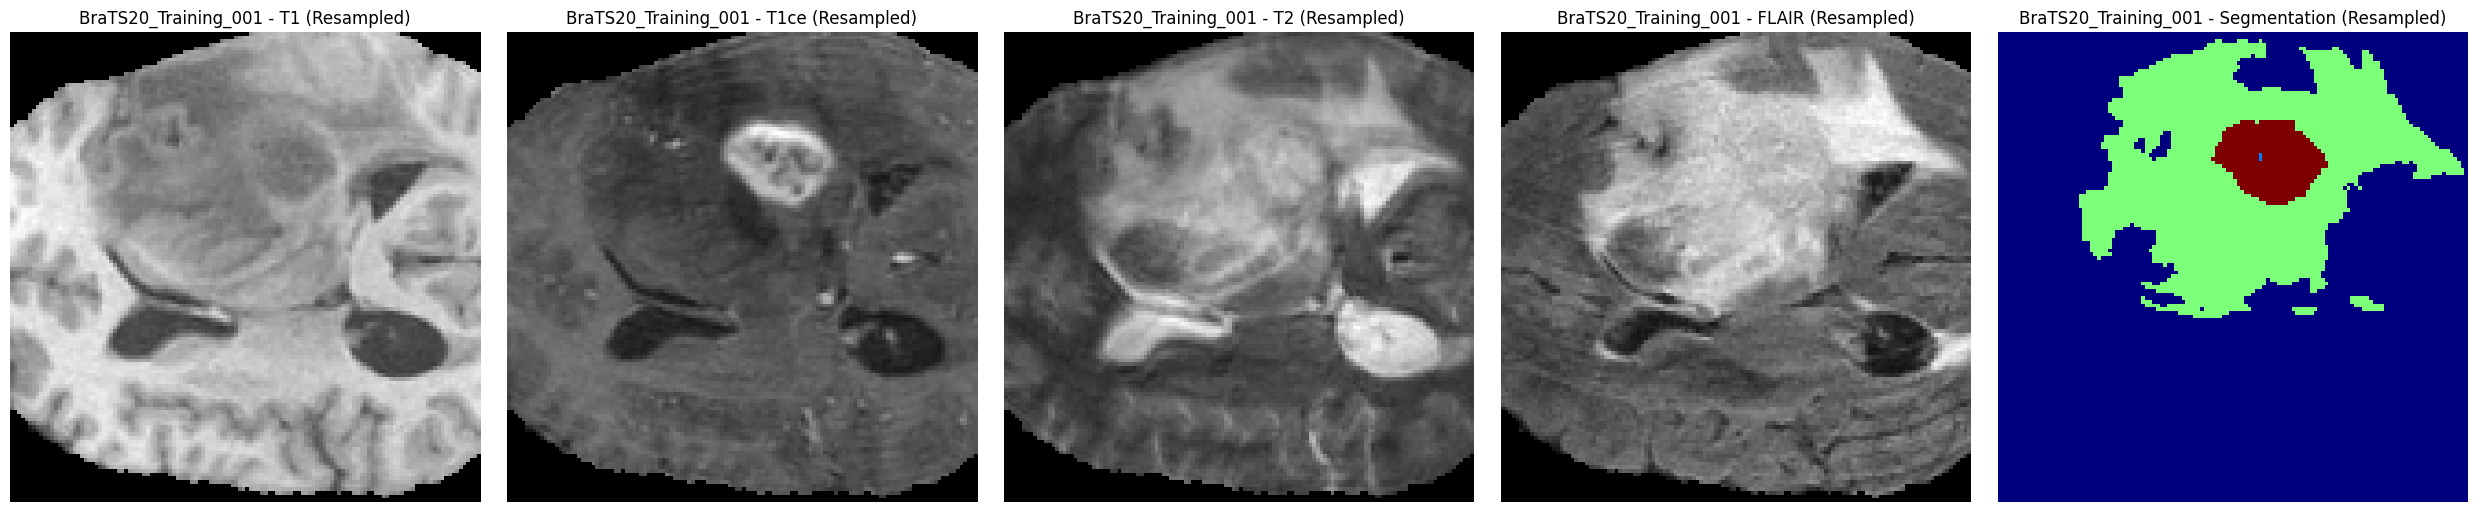

In [14]:
PATIENT_DIR = "BraTS2020/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData/BraTS20_Training_001"
PATIENT_ID = Path(PATIENT_DIR).name
MODALITIES = ["t1", "t1ce", "t2", "flair"]

# 1. Load dữ liệu gốc
volumes = {}
nifti_imgs = {}
for modality in MODALITIES:
    volumes[modality], nifti_imgs[modality] = load_volume(PATIENT_DIR, PATIENT_ID, modality)

seg, seg_img = load_volume(PATIENT_DIR, PATIENT_ID, "seg")
print(f"Unique labels in original seg: {np.unique(seg)}")
seg = seg.astype(np.uint8)

# 2. Lấy thông tin Spacing (Voxel size) gốc
# BraTS thường có spacing sẵn là (1, 1, 1), nhưng code này giúp xử lý cho mọi bộ dữ liệu khác
original_spacing = seg_img.header.get_zooms()[:3] 
TARGET_SPACING = (1, 1, 1)

print(f"\n--- Tiến hành Resample từ Spacing {original_spacing} về {TARGET_SPACING} ---")

# 3. Tiến hành Resample ảnh nhiễu/ảnh cường độ (t1, t2, flair...)
# Sử dụng order=1 (Bilinear) hoặc order=3 (Cubic) cho ảnh cấu trúc
resampled_volumes = {}
for modality in MODALITIES:
    resampled_volumes[modality] = resample_volume(
        volume=volumes[modality], 
        original_spacing=original_spacing, 
        target_spacing=TARGET_SPACING,
        order=1 
    )
    print(f"Resampled {modality:5s} shape: {resampled_volumes[modality].shape}")

# 4. Tiến hành Resample cho file Segmentation (seg)
# ĐẶC BIỆT LƯU Ý: Phải dùng order=0 (Nearest Neighbor) cho nhãn kết quả (0, 1, 2, 4...)
resampled_seg = resample_volume(
    volume=seg, 
    original_spacing=original_spacing, 
    target_spacing=TARGET_SPACING,
    order=0  # Bắt buộc bằng 0 để giữ nguyên giá trị các nhãn (Label) dạng số nguyên
)
print(f"Resampled seg   shape: {resampled_seg.shape}")
print("Unique labels sau resample:", np.unique(resampled_seg))
for i in range(5):
    print(f"Label {i}: {(resampled_seg == i).sum()} voxels")

# 5. Cắt hoặc Pad ảnh về kích thước (128, 128, 128) theo yêu cầu của model
final_volumes = {}
for modality in MODALITIES:
    final_volumes[modality] = crop_or_pad_3d(resampled_volumes[modality], target_shape=(128, 128, 128))
    print(f"Final {modality:5s} shape after crop/pad: {final_volumes[modality].shape}")
final_seg = crop_or_pad_3d(resampled_seg, target_shape=(128, 128, 128))
print(f"Final seg   shape after crop/pad: {final_seg.shape}")

# 6. Kiểm tra lại các lát cắt sau khi resample và crop/pad
slice_idx = final_volumes["flair"].shape[2] // 2
fig, axes = plt.subplots(1, 5, figsize=(25, 5))
axes[0].imshow(final_volumes["t1"][:, :, slice_idx], cmap="gray")
axes[0].set_title(f"{PATIENT_ID} - T1 (Resampled)")
axes[0].axis("off")
axes[1].imshow(final_volumes["t1ce"][:, :, slice_idx], cmap="gray")
axes[1].set_title(f"{PATIENT_ID} - T1ce (Resampled)")
axes[1].axis("off")
axes[2].imshow(final_volumes["t2"][:, :, slice_idx], cmap="gray")
axes[2].set_title(f"{PATIENT_ID} - T2 (Resampled)")
axes[2].axis("off")
axes[3].imshow(final_volumes["flair"][:, :, slice_idx], cmap="gray")
axes[3].set_title(f"{PATIENT_ID} - FLAIR (Resampled)")
axes[3].axis("off")
axes[4].imshow(final_seg[:, :, slice_idx], cmap="jet")
axes[4].set_title(f"{PATIENT_ID} - Segmentation (Resampled)")
axes[4].axis("off")
plt.tight_layout()
plt.show()

In [15]:
def calculate_brats_weights(dataset_dir, target_shape=(128, 128, 128)):
    """
    Quét qua tập dữ liệu BraTS để tính toán trọng số WT, TC, ET 
    dựa trên các hàm tiền xử lý cắt tâm/resize của bạn.
    """
    total_wt_voxels = 0
    total_tc_voxels = 0
    total_et_voxels = 0
    total_voxels = 0
    
    # Tìm tất cả các file nhãn segmentation (_seg.nii hoặc _seg.nii.gz)
    seg_files = []
    for root, dirs, files in os.walk(dataset_dir):
        for f in files:
            if '_seg.nii' in f:
                seg_files.append(os.path.join(root, f))
                
    print(f"🔍 Tìm thấy {len(seg_files)} file nhãn để tính toán...")
    
    for file_path in tqdm(seg_files, desc="Đang quét dữ liệu"):
        seg_img = nib.load(file_path).get_fdata()
        
        # --- ĐỌC LOGIC TỪ CODE TIỀN XỬ LÝ CỦA BẠN ---
        # Giả sử bạn đã đưa volume nhãn về 128x128x128 giống lúc train:
        # (Nếu tính trên ảnh gốc, bạn chỉ cần bỏ qua bước resize/crop)
        
        # BraTS Convention gốc: 
        # Label 1: Necrotic/Non-enhancing tumor
        # Label 2: Peritumoral edema
        # Label 4: GD-enhancing tumor
        
        # 1. Định nghĩa các vùng dựa trên tổ hợp nhãn
        wt_mask = (seg_img == 1) | (seg_img == 2) | (seg_img == 4)  # Toàn bộ u
        tc_mask = (seg_img == 1) | (seg_img == 4)                  # Lõi u
        et_mask = (seg_img == 4)                                  # U bắt thuốc
        
        total_wt_voxels += np.sum(wt_mask)
        total_tc_voxels += np.sum(tc_mask)
        total_et_voxels += np.sum(et_mask)
        total_voxels += seg_img.size

    # 2. Tính tần suất xuất hiện (Probability)
    p_wt = total_wt_voxels / total_voxels
    p_tc = total_tc_voxels / total_voxels
    p_et = total_et_voxels / total_voxels
    
    # 3. Áp dụng công thức làm mịn Logarithmic Inverse 
    # Công thức này rất phổ biến để ra được dải trọng số từ 1.0 đến 4.0
    w_wt = np.log(1 + (1 / (p_wt + 1e-6)))
    w_tc = np.log(1 + (1 / (p_tc + 1e-6)))
    w_et = np.log(1 + (1 / (p_et + 1e-6)))
    
    # Chuẩn hóa để trọng số nhỏ nhất (của WT) bắt đầu quanh mức mong muốn của paper
    # Hoặc sử dụng trực tiếp tỷ lệ nghịch có căn bậc: (1 / p)**0.25
    
    print("\n📊 Kết quả trọng số tính toán được:")
    print(f"self.w_wt = {w_wt:.2f}")
    print(f"self.w_tc = {w_tc:.2f}")
    print(f"self.w_et = {w_et:.2f}")
    
    return w_wt, w_tc, w_et

In [16]:
dataset_path = "BraTS2020/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData"
calculate_brats_weights(dataset_path)

🔍 Tìm thấy 368 file nhãn để tính toán...


Đang quét dữ liệu: 100%|██████████| 368/368 [00:44<00:00,  8.29it/s]


📊 Kết quả trọng số tính toán được:
self.w_wt = 4.51
self.w_tc = 5.37
self.w_et = 6.12


(np.float64(4.508359791715112),
 np.float64(5.37139502749082),
 np.float64(6.123806197971883))

# DATASET & DATALOADER

In [ ]:
class BraTSDataset3D(Dataset):
    def __init__(self, patient_dirs, target_spacing=(1, 1, 1), target_size=(128, 128, 128)):
        self.patient_dirs = [Path(p) for p in patient_dirs] 
        self.target_spacing = target_spacing
        self.target_size = target_size
        self.modalities = ["t1ce", "t2", "flair"]
        
        print(f"Dataset đã khởi tạo thành công với: {len(self.patient_dirs)} bệnh nhân.")

    def __len__(self):
        return len(self.patient_dirs)

    def __getitem__(self, idx):
        patient_dir = self.patient_dirs[idx]
        patient_id  = patient_dir.name

        try:
            volumes = {}
            for modality in self.modalities:
                volumes[modality], _ = load_volume(patient_dir, patient_id, modality)

            seg, seg_img = load_volume(patient_dir, patient_id, "seg")
            seg = seg.astype(np.uint8)

            original_spacing = seg_img.header.get_zooms()[:3]

            # 1. Resample về target_spacing (1, 1, 1) theo lý thuyết
            if not np.allclose(original_spacing, self.target_spacing, rtol=1e-3):
                resampled_volumes = {
                    mod: resample_volume(volumes[mod], original_spacing, self.target_spacing, order=1)
                    for mod in self.modalities
                }
                resampled_seg = resample_volume(seg, original_spacing, self.target_spacing, order=0)
            else:
                resampled_volumes = volumes
                resampled_seg     = seg

            # 2. Cắt hoặc Pad về target_size (128, 128, 128)
            cropped_volumes = {
                mod: crop_or_pad_3d(resampled_volumes[mod], self.target_size)
                for mod in self.modalities
            }
            cropped_seg = crop_or_pad_3d(resampled_seg, self.target_size)

            # 3. Chuẩn hóa Min-Max chỉ dựa trên vùng não (Voxel > 0)
            for modality in self.modalities:
                vol = cropped_volumes[modality]
                mask_brain = vol > 0  # Loại bỏ vùng nền đen
                
                if np.any(mask_brain):
                    vmin, vmax = vol[mask_brain].min(), vol[mask_brain].max()
                    # Chuẩn hóa toàn bộ khối dựa trên min/max của vùng não
                    if vmax > vmin:
                        vol_norm = (vol - vmin) / (vmax - vmin)
                        # Đảm bảo giữ nguyên vùng nền bên ngoài bằng 0
                        vol_norm[~mask_brain] = 0
                        cropped_volumes[modality] = vol_norm
                    else:
                        cropped_volumes[modality] = np.zeros_like(vol)
                else:
                    cropped_volumes[modality] = np.zeros_like(vol)

            # Chuyển đổi sang Tensor PyTorch
            image_np = np.stack([cropped_volumes[mod] for mod in self.modalities], axis=0).astype(np.float32)
            mask_np  = cropped_seg.astype(np.int64)

            return torch.from_numpy(image_np), torch.from_numpy(mask_np), patient_id

        except Exception as e:
            print(f"[WARN] Lỗi khi xử lý {patient_id}: {e}")
            return torch.zeros((3, *self.target_size)), torch.zeros(self.target_size).long(), patient_id

In [18]:
TRAINING_DATA_DIR = "BraTS2020/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData"

# Lấy danh sách các đường dẫn con
train_patient_dirs = [p for p in Path(TRAINING_DATA_DIR).iterdir() if p.is_dir()]

# Chia 80/20 bằng train_test_split
train_ds, val_ds = train_test_split(train_patient_dirs, test_size=0.2, random_state=42)
print(f"Số lượng bệnh nhân trong tập huấn luyện: {len(train_ds)}")
print(f"Số lượng bệnh nhân trong tập validation: {len(val_ds)}")

# Khởi tạo dataset thành phẩm (Sử dụng danh sách mảng làm tham số đầu vào)
train_brats_dataset = BraTSDataset3D(
    patient_dirs=train_ds, # Thay tên tham số thành patient_dirs cho rõ nghĩa
    target_spacing=(1, 1, 1),
    target_size=(128, 128, 128)
)
val_brats_dataset = BraTSDataset3D(
    patient_dirs=val_ds,
    target_spacing=(1, 1, 1),
    target_size=(128, 128, 128)
)


# Kiểm tra thử phần tử đầu tiên (Index 0)
if len(train_brats_dataset) > 0:
    print("\n--- Đang test thử lấy 1 mẫu từ Dataset ---")
    img_tensor, mask_tensor, p_id = train_brats_dataset[0]
    print(f"Bệnh nhân lấy thử: {p_id}")
    print(f"Kích thước Image Tensor: {img_tensor.shape} | Dtype: {img_tensor.dtype}")
    print(f"Kích thước Mask Tensor : {mask_tensor.shape} | Dtype: {mask_tensor.dtype}")
    print(f"Các class có trong mask: {torch.unique(mask_tensor)}")
    
    # Tích hợp vào DataLoader của PyTorch để phục vụ Training
    print("\n--- Đang test thử khởi tạo PyTorch DataLoader ---")
    train_loader = DataLoader(
        dataset=train_brats_dataset,
        batch_size=2,        # Thường ảnh 3D rất nặng nên batch_size từ 1-4 tùy VRAM
        shuffle=True,
        num_workers=2,        # Số lượng tiến trình CPU dùng để load data song song
        persistent_workers=True  # Giữ tiến trình worker giữa các epoch để tăng tốc độ load dữ liệu sau epoch đầu tiên
    )
    val_loader = DataLoader(
        dataset=val_brats_dataset,
        batch_size=2,
        shuffle=False,
        num_workers=2,
        persistent_workers=True  # Giữ tiến trình worker giữa các epoch để tăng tốc độ load dữ liệu sau epoch đầu tiên
    )
    
    # Thử lấy 1 batch dữ liệu đầu tiên
    for batch_idx, (batch_images, batch_masks, batch_ids) in enumerate(train_loader):
        print(f"Batch index: {batch_idx}")
        print(f"Batch Images shape: {batch_images.shape}") # Expect: (batch_size, 4, 128, 128, 128)
        print(f"Batch Masks shape : {batch_masks.shape}")  # Expect: (batch_size, 128, 128, 128)
        print(f"Danh sách bệnh nhân trong batch: {batch_ids}")
        break # Chỉ chạy thử 1 vòng lặp để kiểm tra

Số lượng bệnh nhân trong tập huấn luyện: 295
Số lượng bệnh nhân trong tập validation: 74
Dataset đã khởi tạo thành công với: 295 bệnh nhân.
Dataset đã khởi tạo thành công với: 74 bệnh nhân.

--- Đang test thử lấy 1 mẫu từ Dataset ---
Bệnh nhân lấy thử: BraTS20_Training_345
Kích thước Image Tensor: torch.Size([3, 128, 128, 128]) | Dtype: torch.float32
Kích thước Mask Tensor : torch.Size([128, 128, 128]) | Dtype: torch.int64
Các class có trong mask: tensor([0, 1, 2, 4])

--- Đang test thử khởi tạo PyTorch DataLoader ---
Batch index: 0
Batch Images shape: torch.Size([2, 3, 128, 128, 128])
Batch Masks shape : torch.Size([2, 128, 128, 128])
Danh sách bệnh nhân trong batch: ('BraTS20_Training_246', 'BraTS20_Training_021')


In [19]:
train_loader.dataset.patient_dirs[:5]

[WindowsPath('BraTS2020/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData/BraTS20_Training_345'),
 WindowsPath('BraTS2020/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData/BraTS20_Training_193'),
 WindowsPath('BraTS2020/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData/BraTS20_Training_076'),
 WindowsPath('BraTS2020/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData/BraTS20_Training_085'),
 WindowsPath('BraTS2020/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData/BraTS20_Training_358')]

In [20]:
val_loader.dataset.patient_dirs[:5]

[WindowsPath('BraTS2020/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData/BraTS20_Training_327'),
 WindowsPath('BraTS2020/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData/BraTS20_Training_034'),
 WindowsPath('BraTS2020/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData/BraTS20_Training_016'),
 WindowsPath('BraTS2020/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData/BraTS20_Training_346'),
 WindowsPath('BraTS2020/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData/BraTS20_Training_058')]

In [21]:
def get_param_groups(model, weight_decay=0.02):
    l2_modules = ['enc3', 'dec3']
    
    l2_params = []
    no_l2_params = []
    
    for name, param in model.named_parameters():
        if any(m in name for m in l2_modules):
            l2_params.append(param)
        else:
            no_l2_params.append(param)
    
    return [
        {'params': no_l2_params, 'weight_decay': 0.0},
        {'params': l2_params,    'weight_decay': weight_decay},
    ]

In [22]:
# Khởi tạo model
model = LATUPNet(in_channels=3, num_classes=4, use_se=True, dropout_rate=0.2).to(device)
# Khởi tạo optimizer 
optimizer = Adam(
    get_param_groups(model, weight_decay=0.02),
    lr=1e-4,
    betas=(0.9, 0.999)
)
# Khởi tạo loss function    
criterion = WeightedDiceLoss()

# COMPUTE EVALUATION METRICS

In [23]:
def get_region_masks(pred_np, true_np):
    """
    Trả về dict binary masks cho WT, TC, ET.
    pred_np : (H,W,D) values {0,1,2,3}   (channel index)
    true_np : (H,W,D) values {0,1,2,4}   (BraTS label)
    """
    regions = {
        # WT = NCR(1) + ED(2) + ET(3/4)
        "WT": {
            "pred": np.isin(pred_np, [1, 2, 3]),
            "true": np.isin(true_np, [1, 2, 4]),
        },
        # TC = NCR(1) + ET(3/4)
        "TC": {
            "pred": np.isin(pred_np, [1, 3]),
            "true": np.isin(true_np, [1, 4]),
        },
        # ET only
        "ET": {
            "pred": pred_np == 3,
            "true": true_np == 4,
        },
    }
    return regions

In [24]:
def dice_score(pred_bin, true_bin, eps=1e-5):
    inter = np.sum(pred_bin & true_bin)
    union = np.sum(pred_bin) + np.sum(true_bin)
    if union == 0:
        return 1.0  # cả hai đều rỗng → hoàn hảo
    return (2.0 * inter + eps) / (union + eps)
 
 
def iou_score(pred_bin, true_bin, eps=1e-5):
    inter = np.sum(pred_bin & true_bin)
    union = np.sum(pred_bin | true_bin)
    if union == 0:
        return 1.0
    return (inter + eps) / (union + eps)
 
 
def recall_score(pred_bin, true_bin, eps=1e-5):
    """Sensitivity / TPR"""
    tp = np.sum(pred_bin & true_bin)
    fn = np.sum(~pred_bin & true_bin)
    if (tp + fn) == 0:
        return 1.0
    return (tp + eps) / (tp + fn + eps)
 
 
def f1_score_seg(pred_bin, true_bin, eps=1e-5):
    """F1 = Dice (chúng đồng nhất với nhau trong segmentation)"""
    return dice_score(pred_bin, true_bin, eps)
 
 
def hausdorff95(pred_bin, true_bin, spacing=(1.0, 1.0, 1.0)):
    """
    HD95 — khoảng cách Hausdorff phân vị 95.
    Trả về 0.0 nếu một trong hai mask rỗng (trường hợp đặc biệt).
    """
    if not pred_bin.any() or not true_bin.any():
        return 0.0
 
    # Distance transform tính khoảng cách từ biên (EDT trên ~mask cho ra dist đến mask)
    dist_pred_to_true = distance_transform_edt(~true_bin, sampling=spacing)
    dist_true_to_pred = distance_transform_edt(~pred_bin, sampling=spacing)
 
    # Lấy khoảng cách tại các điểm trên biên của mask kia
    d1 = dist_pred_to_true[pred_bin]
    d2 = dist_true_to_pred[true_bin]
 
    hd95 = max(np.percentile(d1, 95), np.percentile(d2, 95))
    return float(hd95)
 
 
def assd(pred_bin, true_bin, spacing=(1.0, 1.0, 1.0)):
    """
    ASSD — Average Symmetric Surface Distance.
    Trả về 0.0 nếu một trong hai mask rỗng.
    """
    if not pred_bin.any() or not true_bin.any():
        return 0.0
 
    dist_pred_to_true = distance_transform_edt(~true_bin, sampling=spacing)
    dist_true_to_pred = distance_transform_edt(~pred_bin, sampling=spacing)
 
    d1 = dist_pred_to_true[pred_bin]
    d2 = dist_true_to_pred[true_bin]
 
    return float((np.mean(d1) + np.mean(d2)) / 2.0)

In [25]:
def compute_metrics(pred_np, true_np, spacing=(1.0, 1.0, 1.0)):
    """
    Tính toàn bộ metrics cho 1 ca bệnh.
    
    Args:
        pred_np : (H,W,D) numpy array, values {0,1,2,3}
        true_np : (H,W,D) numpy array, values {0,1,2,4}
        spacing : voxel spacing sau resampling (mặc định 1mm isotropic)
    
    Returns:
        dict với keys: DSC_WT, DSC_TC, DSC_ET,
                       HD95_WT, HD95_TC, HD95_ET,
                       IoU_WT, IoU_TC, IoU_ET,
                       Recall_WT, Recall_TC, Recall_ET,
                       F1_WT, F1_TC, F1_ET,
                       ASSD_WT, ASSD_TC, ASSD_ET
    """
    regions = get_region_masks(pred_np, true_np)
    results = {}
 
    for region, masks in regions.items():
        p = masks["pred"]
        t = masks["true"]
        results[f"DSC_{region}"]    = dice_score(p, t)
        results[f"HD95_{region}"]   = hausdorff95(p, t, spacing)
        results[f"IoU_{region}"]    = iou_score(p, t)
        results[f"Recall_{region}"] = recall_score(p, t)
        results[f"F1_{region}"]     = f1_score_seg(p, t)
        results[f"ASSD_{region}"]   = assd(p, t, spacing)
 
    return results
 
 
def average_metrics(metrics_list):
    """Trung bình metrics qua nhiều ca bệnh."""
    if not metrics_list:
        return {}
    keys = metrics_list[0].keys()
    return {k: float(np.mean([m[k] for m in metrics_list])) for k in keys}

In [26]:
def compute_gflops(model, input_size=(1, 3, 128, 128, 128), device="cuda"):
    """
    Tính GFLOPs dùng thop (pip install thop).
    Trả về (macs_G, params_M).
    """
    try:
        from thop import profile as thop_profile
 
        dummy = torch.randn(*input_size).to(device)
        model_cpu = model.to(device)
        macs, params = thop_profile(model_cpu, inputs=(dummy,), verbose=False)
        gflops = macs / 1e9  # MACs → GFLOPs (1 MAC ≈ 2 FLOPs, nhưng thường báo GMACs)
        params_m = params / 1e6
        print(f"GFLOPs: {gflops:.2f} G | Params: {params_m:.2f} M")
        return gflops, params_m
    except ImportError:
        print("Chưa cài thop. Chạy: pip install thop")
        return None, None

In [27]:
def measure_inference_time(model, dataloader, device, n_warmup=3):
    """
    Đo thời gian inference trung bình mỗi ca bệnh (ms/case).
    
    Args:
        n_warmup: số batch bỏ qua để GPU warm up trước khi đo
    
    Returns:
        avg_time_ms: thời gian trung bình ms/case
    """
    model.eval()
    times = []
 
    with torch.no_grad():
        for i, (images, masks, patient_ids) in enumerate(dataloader):
            images = images.to(device)
            batch_size = images.shape[0]
 
            # GPU warm-up: không tính vào kết quả
            if i < n_warmup:
                _ = model(images)
                torch.cuda.synchronize()
                continue
 
            # Đo thời gian chính xác bằng CUDA event
            start_event = torch.cuda.Event(enable_timing=True)
            end_event   = torch.cuda.Event(enable_timing=True)
 
            start_event.record()
            _ = model(images)
            end_event.record()
 
            torch.cuda.synchronize()
            elapsed_ms = start_event.elapsed_time(end_event)  # ms cho cả batch
 
            # Chia cho batch size để được ms/case
            times.extend([elapsed_ms / batch_size] * batch_size)
 
    avg_time_ms = float(np.mean(times)) if times else 0.0
    print(f"Inference time: {avg_time_ms:.2f} ms/case")
    return avg_time_ms

# TRAINING MODEL

In [28]:
def generate_final_report(metrics_list):
    """Tính toán và in ra định dạng Mean ± Std chuẩn kết quả nghiên cứu."""
    if not metrics_list: 
        return {}
    
    keys = metrics_list[0].keys()
    report_summary = {}
    
    for k in keys:
        raw_values = [m[k] for m in metrics_list]
        report_summary[f"{k}_mean"] = np.mean(raw_values)
        report_summary[f"{k}_std"] = np.std(raw_values)
        
    # Xác định xem DSC có cần scale lên % không (nếu output dạng 0.0 -> 1.0)
    scale = 100.0 if report_summary["DSC_WT_mean"] <= 1.0 else 1.0
    
    print("\n📊 " + "═"*20 + " FINAL REPORT: MEAN ± STD " + "═"*20)
    print(f" ▪️ DSC WT (%)  : {report_summary['DSC_WT_mean']*scale:.2f} ± {report_summary['DSC_WT_std']*scale:.2f}")
    print(f" ▪️ DSC TC (%)  : {report_summary['DSC_TC_mean']*scale:.2f} ± {report_summary['DSC_TC_std']*scale:.2f}")
    print(f" ▪️ DSC ET (%)  : {report_summary['DSC_ET_mean']*scale:.2f} ± {report_summary['DSC_ET_std']*scale:.2f}")
    print(f" ──────────────────────────────────────────────────")
    print(f" ▪️ HD95 WT (mm): {report_summary['HD95_WT_mean']:.2f} ± {report_summary['HD95_WT_std']:.2f}")
    print(f" ▪️ HD95 TC (mm): {report_summary['HD95_TC_mean']:.2f} ± {report_summary['HD95_TC_std']:.2f}")
    print(f" ▪️ HD95 ET (mm): {report_summary['HD95_ET_mean']:.2f} ± {report_summary['HD95_ET_std']:.2f}")
    print("═"*66 + "\n")
    
    return report_summary

In [29]:
def train_one_epoch(model, dataloader, optimizer, criterion, device, epoch=None, log_wandb=True):
    """
    Train 1 epoch, log train loss vào W&B.
    """
    model.train()
    epoch_loss = 0.0
 
    for batch_idx, (images, masks, patient_ids) in tqdm(
        enumerate(dataloader), total=len(dataloader), desc="Training", unit="batch", leave=False
    ):
        images = images.to(device)
        masks  = masks.to(device)
 
        optimizer.zero_grad()
        outputs = model(images)
        loss    = criterion(outputs, masks)
        loss.backward()
        optimizer.step()
 
        epoch_loss += loss.item()
 
        # Log batch-level loss (optional — có thể comment nếu quá nhiều)
        if log_wandb:
            wandb.log({"train/batch_loss": loss.item()})
 
        if (batch_idx + 1) % 50 == 0:
            print(f"  Batch {batch_idx+1}/{len(dataloader)} | Loss: {loss.item():.4f}")
 
    avg_loss = epoch_loss / len(dataloader)
    print(f"Train Loss: {avg_loss:.4f}")
 
    if log_wandb:
        log_dict = {"train/epoch_loss": avg_loss}
        if epoch is not None:
            log_dict["epoch"] = epoch
        wandb.log(log_dict)
 
    return avg_loss

In [30]:
def evaluate(model, dataloader, criterion, device, epoch=None, log_wandb=True):
    model.eval()
    eval_loss = 0.0
    all_metrics = []
    with torch.no_grad():
        for images, masks, patient_ids in tqdm(dataloader, desc="Evaluating", unit="batch", leave=False):
            images, masks = images.to(device), masks.to(device)
            outputs = model(images)
            loss = criterion(outputs, masks)
            eval_loss += loss.item()

            preds_np = torch.argmax(outputs, dim=1).cpu().numpy()
            masks_np = masks.cpu().numpy()

            for i in range(preds_np.shape[0]):
                m = compute_metrics(preds_np[i], masks_np[i], spacing=(1.0, 1.0, 1.0))
                all_metrics.append(m)

    avg_loss = eval_loss / len(dataloader)
    avg_metrics = average_metrics(all_metrics)

    print(f"Val Loss : {avg_loss:.4f}")
    print(f"DSC  WT/TC/ET : {avg_metrics['DSC_WT']:.4f} / {avg_metrics['DSC_TC']:.4f} / {avg_metrics['DSC_ET']:.4f}")

    if log_wandb:
        log_dict = {"val/loss": avg_loss}
        for k, v in avg_metrics.items(): log_dict[f"val/{k}"] = v
        if epoch is not None: log_dict["epoch"] = epoch
        wandb.log(log_dict)

    return avg_loss, all_metrics # Trả về list metrics thô để tái sử dụng cuối pipeline

In [ ]:
save_path = "best_latupnet_15.pth"
num_epochs = 2
project_name = "BraTS2020_Segmentation"
run_name = f"LATUPNet_Epoch{num_epochs}_Adam_LR1e-4_WeightedDiceLoss"

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Khởi tạo Model & Nguyên tắc tính trước W&B để lấy thông tin config chính xác
model = LATUPNet(in_channels=3, num_classes=4, use_se=True, dropout_rate=0.2).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4, betas=(0.9, 0.999))
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10, eta_min=1e-6)
criterion = WeightedDiceLoss()

wandb.init(
    project=project_name,
    name=run_name,
    config={
        "epochs":      num_epochs,
        "optimizer":   "Adam",
        "lr":          optimizer.param_groups[0]["lr"], 
        "loss":        "WeightedDiceLoss",
        "model":       "LATUP-Net",
        "input_size":  "128x128x128",
        "in_channels": 3,
        "num_classes": 4,
    },
)
wandb.watch(model, log="gradients", log_freq=100)

# Load data
TRAINING_DATA_DIR = "BraTS2020/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData"
train_patient_dirs = [p for p in Path(TRAINING_DATA_DIR).iterdir() if p.is_dir()]
train_ds, val_ds = train_test_split(train_patient_dirs, test_size=0.2, random_state=42)

train_brats_dataset = BraTSDataset3D(patient_dirs=train_ds, target_spacing=(1,1,1), target_size=(128,128,128))
val_brats_dataset   = BraTSDataset3D(patient_dirs=val_ds,   target_spacing=(1,1,1), target_size=(128,128,128))

train_loader = DataLoader(train_brats_dataset, batch_size=1, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_brats_dataset,   batch_size=1, shuffle=False, num_workers=0)

# Khởi tạo tracking biến tốt nhất
best_val_loss = float("inf")
best_epoch = -1

train_losses, val_losses = [], []

# Vòng lặp chính
for epoch in range(1, num_epochs + 1):
    print(f"\n{'─'*50}\nEpoch {epoch}/{num_epochs}")
    
    train_loss = train_one_epoch(model, train_loader, optimizer, criterion, device, epoch=epoch, log_wandb=True)
    val_loss, raw_val_metrics = evaluate(model, val_loader, criterion, device, epoch=epoch, log_wandb=True)
    
    scheduler.step()
    wandb.log({"train/lr": optimizer.param_groups[0]["lr"], "epoch": epoch})

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_epoch = epoch
        torch.save(model.state_dict(), save_path)
        print(f"✅ Saved best model | val_loss={val_loss:.4f} tại Epoch {epoch}")


# =========================================================================
# 5. ĐÁNH GIÁ CUỐI CÙNG CHO BEST MODEL (FINAL SUMMARY FOR REPORT)
# =========================================================================
print(f"\n{'='*50}\n Huấn luyện kết thúc. Đang tiến hành kết xuất báo cáo...\n{'='*50}")

# Tải lại trọng số tối ưu nhất
if Path(save_path).exists():
    print(f"🔄 Đang tải checkpoint tốt nhất từ: {save_path} (Epoch {best_epoch})...")
    model.load_state_dict(torch.load(save_path))

# Đánh giá lại để lấy danh sách metrics chi tiết (Tắt log tuần tự lên W&B)
final_loss, final_raw_metrics = evaluate(model, val_loader, criterion, device, epoch=best_epoch, log_wandb=False)

# Đo thời gian suy luận trên mô hình tốt nhất này
avg_inf_ms = measure_inference_time(model, val_loader, device)

# Xuất bảng số liệu thống kê Mean ± Std ra màn hình
final_report_data = generate_final_report(final_raw_metrics)

# Đồng bộ các chỉ số báo cáo tĩnh lên W&B Summary Dashboard
wandb.summary["best_epoch"] = best_epoch
wandb.summary["best_val/loss"] = final_loss
wandb.summary["inference/time_ms_per_case"] = avg_inf_ms

for key_metric, val_metric in final_report_data.items():
    wandb.summary[f"report/{key_metric}"] = val_metric

wandb.finish()

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from C:\Users\nlhnh\_netrc.
wandb: Currently logged in as: nlhnhenry (nlhnhenry-fpt-university) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Dataset đã khởi tạo thành công với: 295 bệnh nhân.
Dataset đã khởi tạo thành công với: 74 bệnh nhân.

──────────────────────────────────────────────────
Epoch 1/2


Training:  17%|█▋        | 50/295 [09:41<47:25, 11.61s/batch] 

  Batch 50/295 | Loss: 26.3646


Training:  34%|███▍      | 100/295 [19:22<38:04, 11.71s/batch]

...

Train Loss: 17.2002


C:\Users\nlhnh\AppData\Local\Temp\ipykernel_8280\2372942796.py:75: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(save_path))


Val Loss : 14.8875
DSC  WT/TC/ET : 0.7674 / 0.6319 / 0.5547
✅ Saved best model | val_loss=14.8875 tại Epoch 2

 Huấn luyện kết thúc. Đang tiến hành kết xuất báo cáo...
🔄 Đang tải checkpoint tốt nhất từ: best_latupnet_15.pth (Epoch 2)...


Val Loss : 14.8875
DSC  WT/TC/ET : 0.7674 / 0.6319 / 0.5547
Inference time: 338.45 ms/case

📊 ════════════════════ FINAL REPORT: MEAN ± STD ════════════════════
 ▪️ DSC WT (%)  : 76.74 ± 16.55
 ▪️ DSC TC (%)  : 63.19 ± 23.82
 ▪️ DSC ET (%)  : 55.47 ± 27.53
 ──────────────────────────────────────────────────
 ▪️ HD95 WT (mm): 17.23 ± 23.97
 ▪️ HD95 TC (mm): 19.98 ± 26.99
 ▪️ HD95 ET (mm): 19.03 ± 28.54
══════════════════════════════════════════════════════════════════



epoch,▁▁▁███
train/batch_loss,█▇▅▅▆▇▅▄▆▇▅▅▇▇█▅▅▃▇▂▁▅▆▇▂▆▇▄▆▇█▂▃█▅▆▄▇▁▇
train/epoch_loss,█▁
train/lr,█▁
val/ASSD_ET,█▁
val/ASSD_TC,█▁
val/ASSD_WT,█▁
val/DSC_ET,▁█
val/DSC_TC,▁█
val/DSC_WT,▁█
+13,...


In [32]:
# TRAINING_DATA_DIR = "BraTS2020/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData"

# train_patient_dirs = [p for p in Path(TRAINING_DATA_DIR).iterdir() if p.is_dir()]
# train_ds, val_ds = train_test_split(train_patient_dirs, test_size=0.2, random_state=42)

# train_brats_dataset = BraTSDataset3D(patient_dirs=train_ds, target_spacing=(1,1,1), target_size=(128,128,128))
# val_brats_dataset   = BraTSDataset3D(patient_dirs=val_ds,   target_spacing=(1,1,1), target_size=(128,128,128))

# train_loader = DataLoader(train_brats_dataset, batch_size=2, shuffle=True,  num_workers=2)
# val_loader   = DataLoader(val_brats_dataset,   batch_size=1, shuffle=False, num_workers=0)

# device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
# model  = LATUPNet(in_channels=3, num_classes=4, use_se=True, dropout_rate=0.2).to(device)

# optimizer = torch.optim.Adam(model.parameters(), lr=1e-4, betas=(0.9, 0.999))
# scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10, eta_min=1e-6)
# criterion = WeightedDiceLoss()

# NUM_EPOCHS   = 200
# best_val_loss = float('inf')
# train_losses, val_losses = [], []

# for epoch in range(NUM_EPOCHS):
#     print(f"\n--- Epoch {epoch+1}/{NUM_EPOCHS} ---")
#     train_loss = train_one_epoch(model, train_loader, optimizer, criterion, device)
#     val_loss   = evaluate(model, val_loader, criterion, device)

#     train_losses.append(train_loss)
#     val_losses.append(val_loss)

#     if val_loss < best_val_loss:
#         best_val_loss = val_loss
#         torch.save(model.state_dict(), "best_latupnet_200.pth")
#         print("Model saved with validation loss: {:.4f}".format(val_loss))

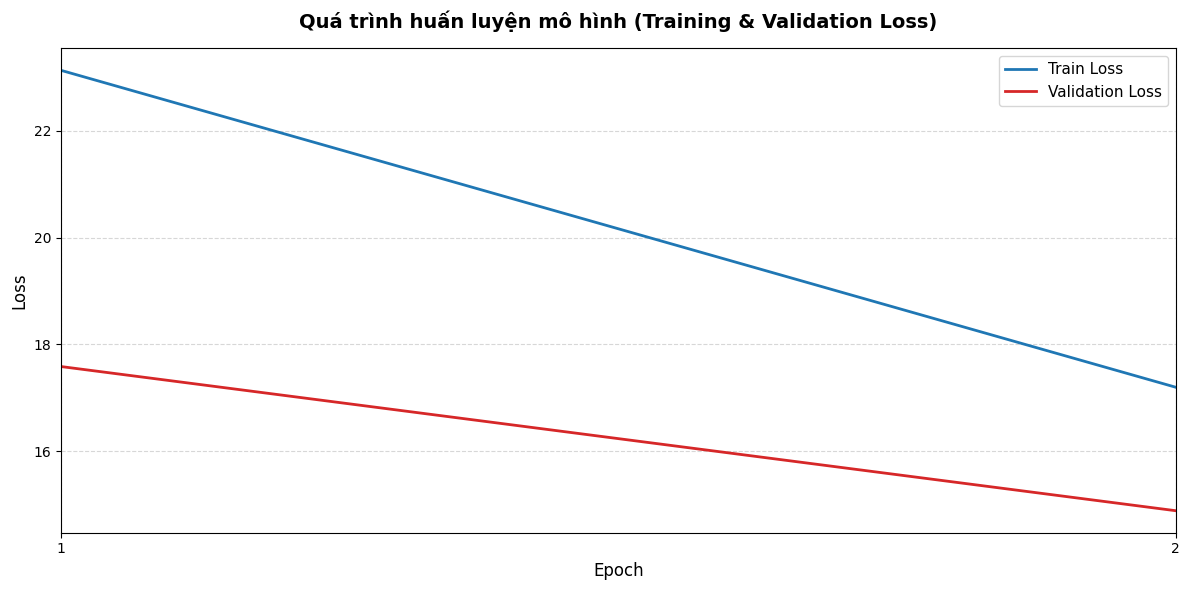

In [47]:
# --- KHỞI TẠO ĐỒ THỊ ---
plt.figure(figsize=(12, 6))

# Vẽ đường Loss
plt.plot(range(1, num_epochs + 1), train_losses, label='Train Loss', color='#1f77b4', linewidth=2)
plt.plot(range(1, num_epochs + 1), val_losses, label='Validation Loss', color='#d62728', linewidth=2)

# Tiêu đề và Nhãn
plt.title('Quá trình huấn luyện mô hình (Training & Validation Loss)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)

# --- GIẢI PHÁP TỰ ĐỘNG CĂN CHỈNH TRỤC X ---
# Giới hạn trục X chuẩn từ epoch 1 đến num_epochs
plt.xlim(1, num_epochs)

# Tự động tính toán khoảng cách (step) cho ticks dựa trên num_epochs
# Giữ cho số lượng nhãn hiển thị trên trục X luôn nằm trong khoảng từ 10 đến 20 nhãn
if num_epochs <= 20:
    step = 1
elif num_epochs <= 50:
    step = 5
elif num_epochs <= 100:
    step = 10
else:
    step = int(num_epochs / 10) # Ví dụ: 200 epochs thì step = 20, 500 epochs thì step = 50

# Tạo danh sách các điểm tick (bắt đầu từ 1, sau đó nhảy theo step, và luôn bao gồm epoch cuối cùng)
x_ticks = list(range(1, num_epochs + 1, step))
if num_epochs not in x_ticks:
    x_ticks.append(num_epochs)

plt.xticks(x_ticks)

# --- TỐI ƯU LƯỚI (GRID) VÀ CHÚ THÍCH ---
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(fontsize=11, loc='upper right')

# Tự động căn chỉnh khoảng cách lề
plt.tight_layout()

# Hiển thị đồ thị
plt.show()

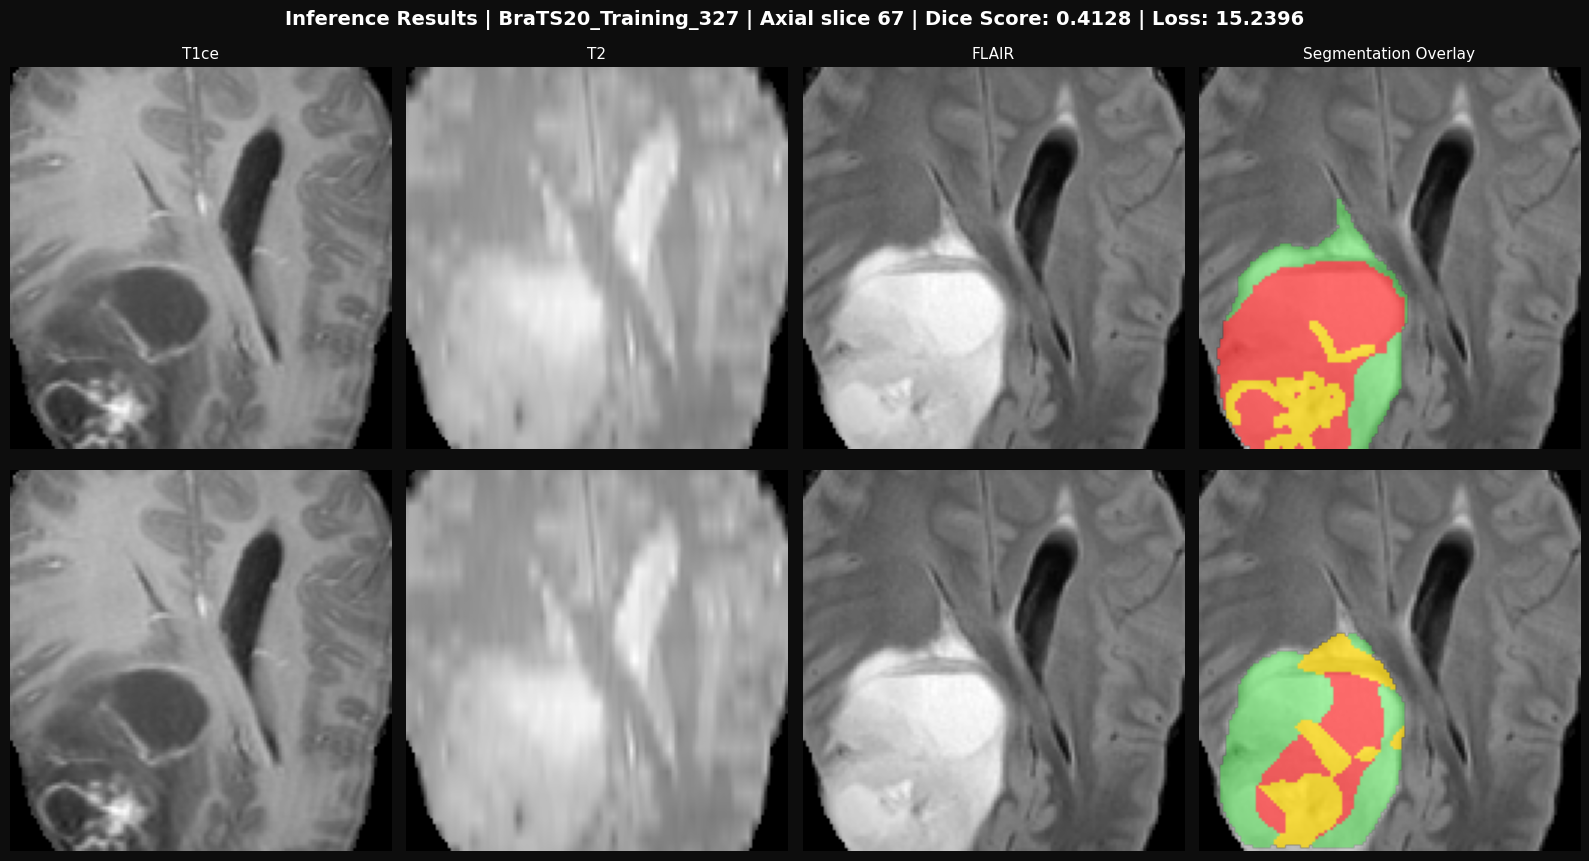

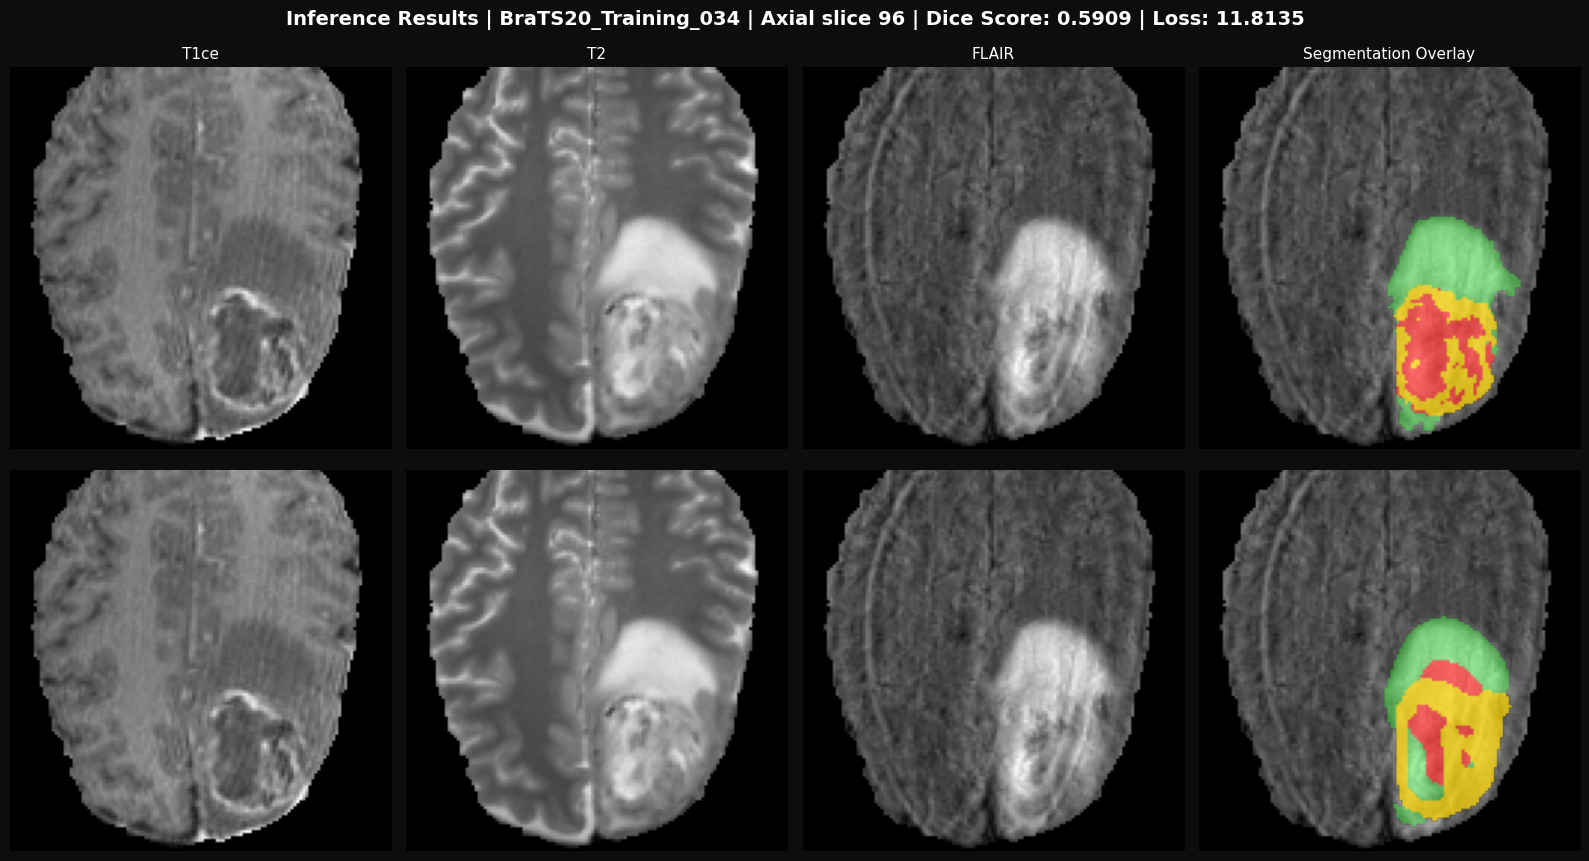

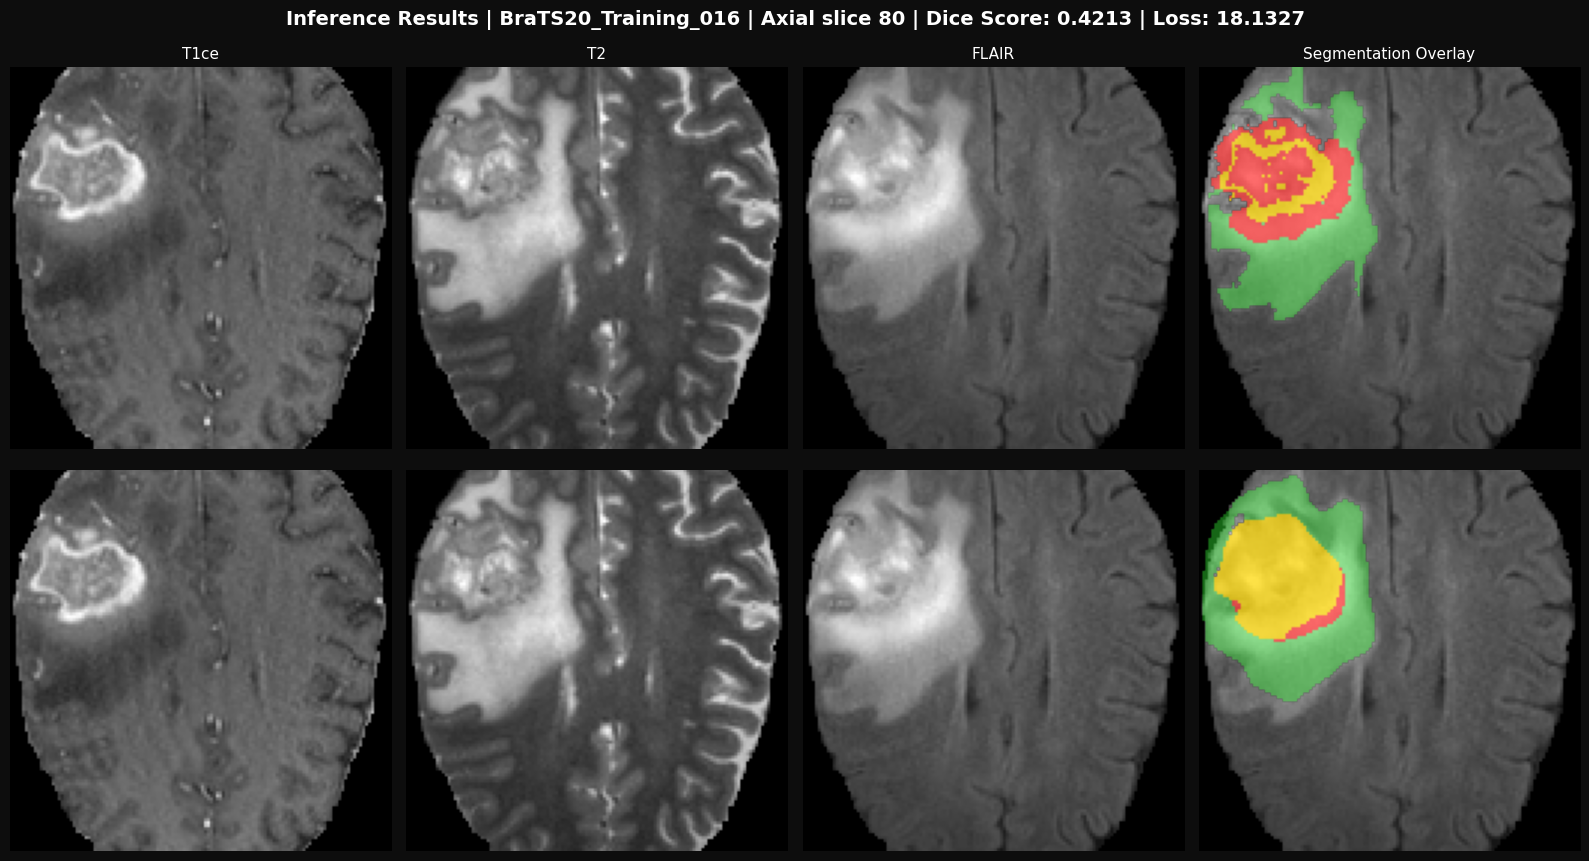

In [34]:
# Giữ nguyên cấu hình màu sắc BraTS đặc trưng của bạn
_COLOR_NCR = (1.0, 0.2,  0.2,  0.72)
_COLOR_ED  = (0.2, 0.9,  0.2,  0.45)
_COLOR_ET  = (1.0, 0.85, 0.0,  0.72)

# Map cho Ground Truth — dùng label BraTS gốc {0,1,2,4}
SEG_RGBA_GT = {1: _COLOR_NCR, 2: _COLOR_ED, 4: _COLOR_ET}

# Map cho Prediction — dùng channel index {0,1,2,3}
SEG_RGBA_PRED = {1: _COLOR_NCR, 2: _COLOR_ED, 3: _COLOR_ET}

def make_seg_rgba(seg_slice, rgba_map):
    rgba = np.zeros((*seg_slice.shape, 4), dtype=np.float32)
    for label, color in rgba_map.items():
        rgba[seg_slice == label] = color
    return rgba

def choose_tumor_slice(seg, is_gt=True):
    labels = [1, 2, 4] if is_gt else [1, 2, 3]
    tumor = np.isin(seg, labels)
    counts = tumor.sum(axis=(0, 1))
    if counts.max() == 0:
        return seg.shape[2] // 2
    return int(counts.argmax())

def calculate_dice_score(pred_np, true_np):
    """pred: {0,1,2,3} (channel index), true: {0,1,2,4} (BraTS labels)"""
    dice_per_class = []
    # Map từng channel pred → label GT tương ứng
    channel_to_gt = {1: 1, 2: 2, 3: 4}
    for pred_ch, gt_label in channel_to_gt.items():
        p_c = (pred_np == pred_ch)
        t_c = (true_np == gt_label)
        inter = np.sum(p_c & t_c)
        union = np.sum(p_c) + np.sum(t_c)
        if union == 0:
            dice_per_class.append(1.0)
        else:
            dice_per_class.append(2.0 * inter / union)
    return np.mean(dice_per_class)


def visualize_predictions_with_scores(model, dataloader, device, criterion=None, num_samples=3):
    """
    Hàm hiển thị kết quả dự đoán tái sử dụng giao diện ma trận ảnh chuyên nghiệp của BraTS.
    Hiển thị 2 hàng x 5 cột:
    - Hàng 1: Ground Truth (T1, T1ce, T2, FLAIR + True Mask Overlay)
    - Hàng 2: Model Prediction (T1, T1ce, T2, FLAIR + Predicted Mask Overlay)
    """
    model.eval()
    samples_visualized = 0
    
    # 1. Định nghĩa danh sách nhãn đầy đủ
    ALL_MODALITIES = ["T1ce", "T2", "FLAIR"]
    
    with torch.no_grad():
        for images, masks, patient_ids in dataloader:
            images_cuda = images.to(device)
            masks_cuda = masks.to(device)
            
            outputs = model(images_cuda)
            preds_cuda = torch.argmax(outputs, dim=1) 
            
            images_np = images.numpy()
            masks_np = masks.numpy()
            preds_np = preds_cuda.cpu().numpy()
            
            # 2. Lấy số lượng modalities thực tế từ hình dạng của tensor (C)
            num_modalities = images.size(1) # Lấy size của axis 1 (C)
            
            # Điều chỉnh nhãn hiển thị tương ứng với số kênh thực tế
            modalities_labels = ALL_MODALITIES[:num_modalities] if num_modalities <= 4 else [f"M{i}" for i in range(num_modalities)]
            
            for i in range(images.size(0)):
                if samples_visualized >= num_samples:
                    return
                
                patient_id = patient_ids[i]
                img_vol = images_np[i]   # (C, H, W, D)
                true_seg = masks_np[i]   # (H, W, D)
                pred_seg = preds_np[i]   # (H, W, D)
                
                # Tính toán Score (sử dụng pred_seg, true_seg dạng numpy như Cách 1 bài trước)
                dice_score = calculate_dice_score(pred_seg, true_seg)
                
                sample_loss_str = ""
                if criterion is not None:
                    sample_loss = criterion(outputs[i].unsqueeze(0), masks_cuda[i].unsqueeze(0))
                    sample_loss_str = f" | Loss: {sample_loss.item():.4f}"
                
                slice_idx = choose_tumor_slice(true_seg)
                
                # 3. Khởi tạo đồ thị với số cột = num_modalities + 1 (cột Overlay)
                num_columns = num_modalities + 1
                fig, axes = plt.subplots(2, num_columns, figsize=(4 * num_columns, 9))
                fig.patch.set_facecolor("#0d0d0d") 
                
                fig.suptitle(
                    f"Inference Results | {patient_id} | Axial slice {slice_idx} | Dice Score: {dice_score:.4f}{sample_loss_str}",
                    color="white", fontsize=14, fontweight="bold", y=0.98
                )
                
                row_labels = ["Ground Truth", "Model Prediction"]
                segs_data = [true_seg, pred_seg] 
                
                for r in range(2):
                    current_seg = segs_data[r]
                    
                    # Vẽ các cột ảnh MRI gốc dựa trên số lượng kênh thực tế
                    for c, modality_name in enumerate(modalities_labels):
                        ax = axes[r, c]
                        ax.imshow(img_vol[c, :, :, slice_idx].T, cmap="gray", origin="lower")
                        
                        if r == 0:
                            ax.set_title(modality_name, color="white", fontsize=11)
                        if c == 0:
                            ax.set_ylabel(row_labels[r], color="#cccccc", fontsize=12, fontweight="bold")
                        ax.axis("off")
                        ax.set_facecolor("black")
                    
                    # 4. Vẽ cột cuối cùng: Overlay nhãn màu lên kênh cuối cùng sẵn có (thường là FLAIR hoặc T2)
                    ax_overlay = axes[r, num_columns - 1]
                    # Sử dụng index [num_modalities - 1] để lấy kênh cuối cùng làm nền thay vì fix cứng index 3
                    ax_overlay.imshow(img_vol[num_modalities - 1, :, :, slice_idx].T, cmap="gray", origin="lower") 
                    rgba_map = SEG_RGBA_GT if r == 0 else SEG_RGBA_PRED
                    ax_overlay.imshow(make_seg_rgba(current_seg[:, :, slice_idx].T, rgba_map), origin="lower")
                    
                    if r == 0:
                        ax_overlay.set_title("Segmentation Overlay", color="white", fontsize=11)
                    ax_overlay.axis("off")
                    ax_overlay.set_facecolor("black")
                
                plt.tight_layout()
                plt.show()
                plt.close()
                
                samples_visualized += 1

# --- CÁCH CHẠY HÀM ---
visualize_predictions_with_scores(model, val_loader, device, criterion=criterion, num_samples=3)

In [35]:
def inference(model, dataloader, device):
    model.eval()
    all_preds = []
    all_masks = []
    all_patient_ids = []

    with torch.no_grad():
        for images, masks, patient_ids in tqdm(dataloader, desc="Inference"):
            images = images.to(device)
            outputs = model(images)
            preds = torch.argmax(outputs, dim=1).cpu().numpy()  # {0,1,2,3}

            # Remap channel 3 → label 4 to align with BraTS convention
            preds_brats = preds.copy()
            preds_brats[preds == 3] = 4  # {0,1,2,4}

            all_preds.append(preds_brats)
            all_masks.append(masks.cpu().numpy())
            all_patient_ids.extend(patient_ids)

    return np.concatenate(all_preds), np.concatenate(all_masks), all_patient_ids
# Run inference on validation set
predictions, true_masks, patient_ids = inference(model, val_loader, device)
print(f"Predictions shape: {predictions.shape}")
print(f"True masks shape: {true_masks.shape}")
print(f"Patient IDs: {patient_ids[:5]}")

Inference: 100%|██████████| 74/74 [00:48<00:00,  1.53it/s]


Predictions shape: (74, 128, 128, 128)
True masks shape: (74, 128, 128, 128)
Patient IDs: ['BraTS20_Training_327', 'BraTS20_Training_034', 'BraTS20_Training_016', 'BraTS20_Training_346', 'BraTS20_Training_058']


In [39]:
def predict_brats_case(model, folder_path, case_id, device, output_dir="./results"):
    model.eval()

    # Paper dùng T1ce, T2, FLAIR — KHÔNG có T1 (Section 4.1)
    modalities = ['_t1ce.nii', '_t2.nii', '_flair.nii']
    volume_list = []
    affine = None
    original_shape = None

    for mod in modalities:
        file_path = os.path.join(folder_path, f"{case_id}{mod}")
        if not os.path.exists(file_path):
            file_path += ".gz"
        nii_img = nib.load(file_path)
        if affine is None:
            affine = nii_img.affine
            original_shape = nii_img.shape  # Lưu lại kích thước gốc (H, W, D) để khôi phục sau này
        img_data = nii_img.get_fdata()

        # Dùng Min-Max [0,1] — đúng với BraTSDataset3D
        vmin, vmax = img_data.min(), img_data.max()
        if vmax > vmin:
            img_data = (img_data - vmin) / (vmax - vmin)
        else:
            img_data = np.zeros_like(img_data)
            
        volume_list.append(img_data)

    # ── THAY THẾ ND_ZOOM BẰNG CROP_OR_PAD_3D ──
    # Xử lý cắt lấy tâm hoặc đệm thêm cạnh độc lập trên từng modality về chuẩn 128x128x128
    processed_volumes = [crop_or_pad_3d(vol, target_shape=(128, 128, 128)) for vol in volume_list]
    
    # Stack các kênh lại với nhau -> Shape hoàn chỉnh: (Ch=3, H=128, W=128, D=128)
    image_data = np.stack(processed_volumes, axis=0)

    # Chuyển đổi tensor và đưa lên thiết bị tính toán (GPU/CPU)
    image_tensor = torch.from_numpy(image_data).float().unsqueeze(0).to(device)

    with torch.no_grad():
        outputs = model(image_tensor)          # (1, 4, 128, 128, 128)
        preds = torch.argmax(outputs, dim=1).squeeze(0).cpu().numpy()  # (128, 128, 128), giá trị nhãn: {0,1,2,3}

    # Map kênh 3 → nhãn 4 theo đúng quy ước cấu trúc dữ liệu của giải đấu BraTS
    preds_brats = preds.copy()
    preds_brats[preds == 3] = 4

    os.makedirs(output_dir, exist_ok=True)
    output_path = os.path.join(output_dir, f"pred_{case_id}.nii")
    
    # ── ĐẢO NGƯỢC QUY TRÌNH: ĐƯA MASK 128³ VỀ LẠI KÍCH THƯỚC GỐC ──
    # Thay vì dùng nd_zoom làm biến dạng biên khối u, ta dùng chính hàm crop_or_pad_3d 
    # để dán (paste) vùng dự đoán về lại đúng tọa độ không gian ban đầu của bệnh nhân.
    full_pred = crop_or_pad_3d(preds_brats, target_shape=original_shape)
    full_pred = full_pred.astype(np.uint8)
    
    # Lưu file NIfTI
    nib.save(nib.Nifti1Image(full_pred, affine), output_path)

    print(f"✅ Saved: {output_path} | Input 128³ processed via Center Crop/Pad.")
    return full_pred  # Trả về mảng {0,1,2,3} kích thước 128³ hỗ trợ trực quan hóa trực tiếp

In [40]:
def visualize_single_prediction(folder_path, case_id, pred_mask, true_mask_path=None):
    """
    Hàm hiển thị kết quả dự đoán cho một ca bệnh đơn lẻ từ đường dẫn file .nii.
    
    Args:
        folder_path (str): Thư mục chứa ca bệnh (để load lại các ảnh MRI gốc).
        case_id (str): Tên ca bệnh.
        pred_mask (np.ndarray): Mảng mask dự đoán dạng NumPy (H, W, D) thu được từ mô hình.
        true_mask_path (str, optional): Đường dẫn tới file nhãn thật nếu có (ví dụ file _seg.nii).
                                       Nếu không truyền, hàm chỉ vẽ phần ảnh gốc và kết quả mô hình tìm được.
    """
    MODALITIES_LABELS = ["T1", "T1ce", "T2", "FLAIR"]
    modalities = ['_t1.nii', '_t1ce.nii', '_t2.nii', '_flair.nii']
    volume_list = []
    
    # 1. Load lại ảnh gốc (dùng để hiển thị làm nền)
    for mod in modalities:
        file_path = os.path.join(folder_path, f"{case_id}{mod}")
        if not os.path.exists(file_path):
            file_path += ".gz"
        nii_img = nib.load(file_path)
        volume_list.append(nii_img.get_fdata())
    
    img_vol = np.stack(volume_list, axis=0) # Shape: (4, H, W, D)
    
    # 2. Kiểm tra xem có nhãn Ground Truth (True Mask) để so sánh hay không
    has_true_mask = False
    true_seg = None
    dice_score_str = ""
    
    if true_mask_path and os.path.exists(true_mask_path):
        true_seg = nib.load(true_mask_path).get_fdata() # (H, W, D)
        has_true_mask = True
        
        # Tính toán nhanh Dice Score (NumPy version)
        _pred_to_gt = {1: 1, 2: 2, 3: 4}
        dice_list = []
        for pred_ch, gt_label in _pred_to_gt.items():
            p_c = (pred_mask == pred_ch)
            t_c = (true_seg == gt_label)
            intersection = np.sum(p_c & t_c)
            union = np.sum(p_c) + np.sum(t_c)
            if union > 0:
                dice_list.append((2.0 * intersection) / union)
        if dice_list:
            dice_score_str = f" | Dice Score: {np.mean(dice_list):.4f}"
            
    # Tự động chọn lát cắt chứa nhiều u nhất (ưu tiên tìm trên true mask, nếu không có thì tìm trên pred mask)
    if has_true_mask:
        slice_idx = choose_tumor_slice(true_seg, is_gt=True)
    else:
        slice_idx = choose_tumor_slice(pred_mask, is_gt=False)
    
    # 3. ĐIỀU CHỈNH SỐ HÀNG ĐỒ THỊ (2 hàng nếu có nhãn thật, 1 hàng nếu chỉ có dự đoán)
    num_rows = 2 if has_true_mask else 1
    fig, axes = plt.subplots(num_rows, 5, figsize=(22, 5 * num_rows))
    fig.patch.set_facecolor("#0d0d0d")
    
    # Đảm bảo axes luôn là mảng 2 chiều kể cả khi chỉ có 1 hàng để tránh lỗi chỉ mục
    if num_rows == 1:
        axes = np.expand_dims(axes, axis=0)
        
    fig.suptitle(
        f"Single Case Evaluation | {case_id} | Axial slice {slice_idx}{dice_score_str}",
        color="white", fontsize=14, fontweight="bold", y=0.98
    )
    
    row_labels = ["Ground Truth", "Model Prediction"] if has_true_mask else ["Model Prediction"]
    segs_data = [true_seg, pred_mask] if has_true_mask else [pred_mask]
    
    for r in range(num_rows):
        current_seg = segs_data[r]
        
        # Vẽ 4 cột ảnh MRI gốc (T1, T1ce, T2, FLAIR)
        for c, modality_name in enumerate(MODALITIES_LABELS):
            ax = axes[r, c]
            ax.imshow(img_vol[c, :, :, slice_idx].T, cmap="gray", origin="lower")
            if r == 0:
                ax.set_title(modality_name, color="white", fontsize=11)
            if c == 0:
                ax.set_ylabel(row_labels[r], color="#cccccc", fontsize=12, fontweight="bold")
            ax.axis("off")
            ax.set_facecolor("black")
        
        # Vẽ cột thứ 5: Overlay nhãn màu lên ảnh xung FLAIR
        ax_overlay = axes[r, 4]
        flair_slice = img_vol[3, :, :, slice_idx].T   # shape (W, H) — rows=W, cols=H

        # Lấy lát cắt mask hiện tại (kích thước 128x128)
        mask_slice = current_seg[:, :, slice_idx].T 
        
        # Nếu kích thước mask khác kích thước ảnh FLAIR, tiến hành resize mask
        if mask_slice.shape != flair_slice.shape:
            from scipy.ndimage import zoom
            zoom_factors = (flair_slice.shape[0] / mask_slice.shape[0], flair_slice.shape[1] / mask_slice.shape[1])
            # Dùng order=0 để giữ nguyên giá trị nhãn (vùng phân vùng không bị mờ nhòe)
            mask_slice = zoom(mask_slice, zoom_factors, order=0)

        rgba_map = SEG_RGBA_GT if r == 0 else SEG_RGBA_PRED
        seg_slice = make_seg_rgba(current_seg[:, :, slice_idx].T, rgba_map)

        # flair_slice.shape = (rows, cols) = (W_orig, H_orig)
        rows, cols = flair_slice.shape
        ext = [0, cols, 0, rows]   # [x_min, x_max, y_min, y_max] = [0, H_orig, 0, W_orig]

        ax_overlay.imshow(flair_slice, cmap="gray", origin="lower", extent=ext)
        ax_overlay.imshow(seg_slice, origin="lower", extent=ext)
        if r == 0:
            ax_overlay.set_title("Segmentation Overlay", color="white", fontsize=11)
        ax_overlay.axis("off")
        ax_overlay.set_facecolor("black")
        
    plt.tight_layout()
    plt.show()
    plt.close()

Đang chạy dự đoán cho ca bệnh: BraTS20_Validation_010
✅ Saved: ./results\pred_BraTS20_Validation_010.nii | Input 128³ processed via Center Crop/Pad.
Predicted mask shape: (240, 240, 155) | Unique values: [0 1 2 4]
Đang hiển thị kết quả dự đoán...


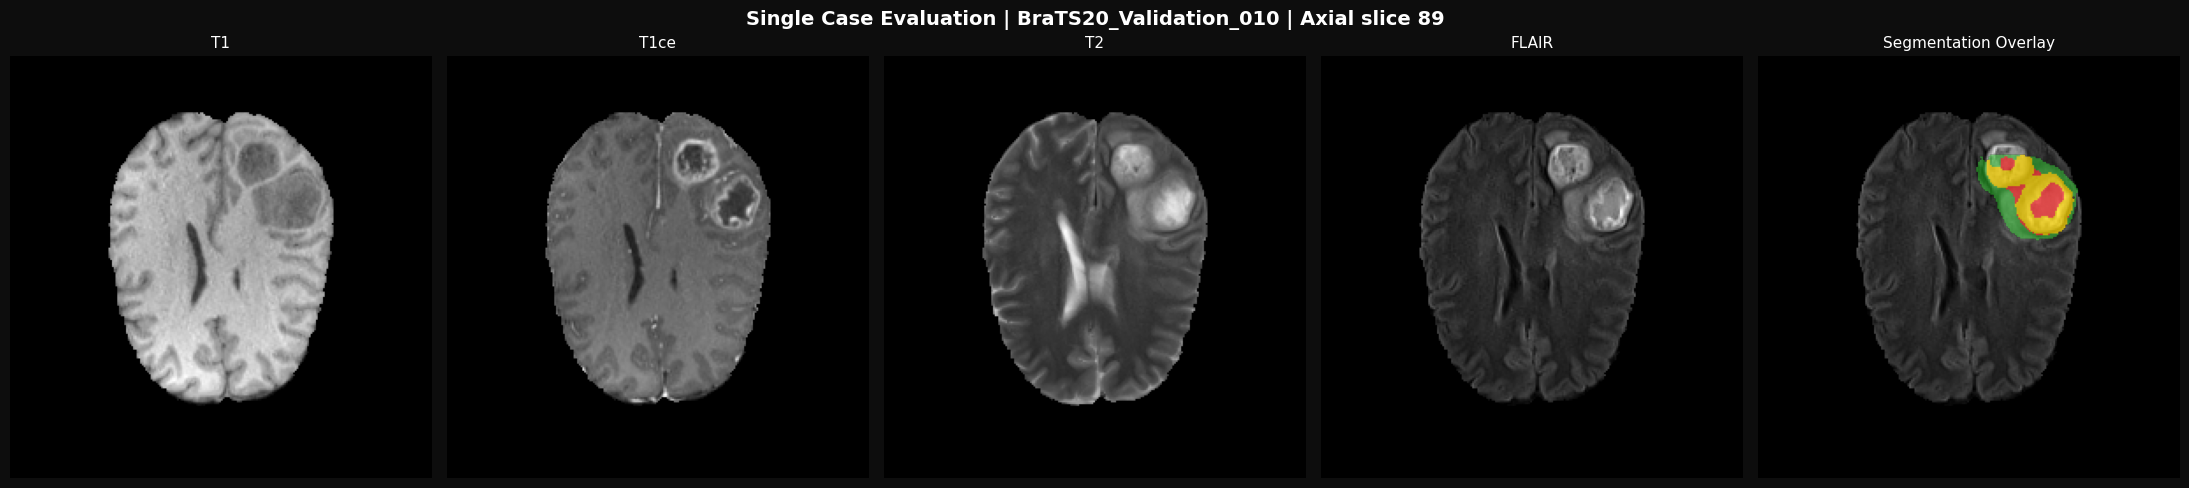

In [44]:
case_folder = "BraTS2020/BraTS2020_ValidationData/MICCAI_BraTS2020_ValidationData/BraTS20_Validation_010"
case_name = "BraTS20_Validation_010"
print(f"Đang chạy dự đoán cho ca bệnh: {case_name}")
pred_mask = predict_brats_case(model, case_folder, case_name, device, output_dir="./results")
print(f"Predicted mask shape: {pred_mask.shape} | Unique values: {np.unique(pred_mask)}")
print("Đang hiển thị kết quả dự đoán...")
visualize_single_prediction(
    folder_path=case_folder, 
    case_id=case_name, 
    pred_mask=pred_mask
)